In [1]:
%load_ext autoreload
%autoreload 2

# Load Imports

In [188]:
from __future__ import annotations
import os
import sys
import copy
import pandas as pd
import numpy as np
import logging
import random
import requests
import pyarrow.parquet as pq

from pathlib import Path, PurePath

# Configure logging
logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s [%(levelname)s] %(message)s")

# Suppress warnings
# logging.getLogger('safety_events').setLevel(logging.WARNING)

# Data quality profiling 
from ydata_profiling import ProfileReport

# Date and Time
import datetime
from datetime import datetime, timezone


# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.path import Path as MplPath
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "notebook_connected"

# Geo
from ipyleaflet import Map, Marker, MarkerCluster, basemaps
from ipywidgets import Dropdown, DatePicker, HBox, VBox, HTML, Output, Label, Layout

# Notebook Utilities
from IPython.display import display, Image, JSON
from tqdm import tqdm

# Duckdb
import duckdb


from typing import Sequence, Iterable, List, Optional, Tuple
from dataclasses import dataclass

# Preprocessing imports
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Baseline pipelines
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, max_error


import matplotlib.pyplot as plt

In [9]:
# Manually set dir if things go awry
os.chdir('C:\\Users\\lover\\Documents\\GitHub\\predicting-safety-events-US-cities-base')

DATA_PATH = None
# Use explicit DATA_PATH, otherwise use relative dir to infer location
#DATA_PATH = PurePath('C:\\Users\\lover\\Documents\\GitHub\\Spotify_Listening_History_Analysis\\data')

# Get current path
cwd = PurePath(Path.cwd())

# Use conditional to ensure we do not traverse to higher level dir.
if not DATA_PATH:
    # Change current working directory from `notebooks` directory to one level above.
    os.chdir('..')    
    
    # Construct path to archive location
    DATA_PATH = cwd / 'data'
    
# Construct query output path
# QUERY_OUTPUT_PATH = cwd / 'data'/ 'sql' / 'query_results'

# Confirm location where data files are stored.
logging.info(str(DATA_PATH))

2026-01-18 02:37:32,136 [INFO] C:\Users\lover\Documents\GitHub\predicting-safety-events-US-cities-base\data


# Load Dataset

In [189]:
# Load parquet file into dataframe
sf_dataframe = pd.read_parquet(DATA_PATH / 'safety-SanFrancisco-2.parquet')
sf_dataframe.head()

,requestId,dataSubtype,dateTime,category,subcategory,status,address,latitude,longitude,source,neighborhood
0,1,911_Fire,2018-10-02 11:54:01,Potentially Life-Threatening,Medical Incident,NaN,ELM ST/FRANKLIN ST,37.781286,-122.422187,NaN,Tenderloin
1,2,311_All,2018-07-08 15:00:27,Street and Sidewalk Cleaning,Bulky Items,Closed,"1536 SACRAMENTO ST, SAN FRANCISCO, CA, 94109",37.791887,-122.418188,Mobile/Open311,Nob Hill
2,3,311_All,2016-06-28 13:12:28,General Request - COUNTY CLERK,customer_callback,Closed,Not associated with a specific address,0.000000,0.000000,Phone,Unknown
3,7,311_All,2017-03-03 09:34:49,Temporary Sign Request,Temporary Sign Request for Other_Event_Type,Closed,"2190 NORTH POINT ST, SAN FRANCISCO, CA, 94123",37.802853,-122.443245,Phone,Marina
4,10,911_Fire,2016-10-25 18:33:20,Potentially Life-Threatening,Medical Incident,NaN,200 Block of DALEWOOD WAY,37.737953,-122.456498,NaN,Portola


In [4]:
sf_dataframe.dtypes

requestId                int64
dataSubtype           category
dateTime        datetime64[ns]
category              category
subcategory           category
status                category
address                 object
latitude               float64
longitude              float64
source                category
neighborhood            object
dtype: object

# Data Preparation and Aggregation

In [190]:
sf_dataframe['category'].unique()

['Potentially Life-Threatening', 'Street and Sidewalk Cleaning', 'General Request - COUNTY CLERK', 'Temporary Sign Request', 'Fire', ..., 'General Request - CITY ATTORNEY', 'General Request - PUBLIC DEFENDER', 'General Request - ADULT PROBATION', 'General Request - GRANTS FOR THE ARTS', 'General Request - CONVENTION FACILITIES']
Length: 96
Categories (95, object): ['311 External Request', 'Abandoned Vehicle', 'Alarm', 'Blocked Street or SideWalk', ..., 'Street and Sidewalk Cleaning', 'Streetlights', 'Temporary Sign Request', 'Tree Maintenance']

There are 95 different categories! Dafuuuq.

> We will create one model per event category, starting with “Potentially Life-Threatening” events.


In [ ]:
duckdb.sql("""
SELECT 
    category
    ,neighborhood
    ,COUNT(category) AS count
FROM sf_dataframe
GROUP BY
    category
    ,neighborhood
ORDER BY count DESC
LIMIT 5
""")

In [ ]:
duckdb.sql("""
SELECT 
    DISTINCT category
    ,COUNT(category) AS count
FROM sf_dataframe
WHERE category = 'Potentially Life-Threatening'
GROUP BY category
ORDER BY count DESC
LIMIT 5
""")

In [192]:
pot_life_threatening = duckdb.sql("""
SELECT * 
FROM sf_dataframe
WHERE category = 'Potentially Life-Threatening'
AND dateTime BETWEEN '2016-01-01' AND '2020-01-01'
AND neighborhood IN 
('Mission', 'SoMa', 'Tenderloin', 'Nob Hill', 'Ingleside')
""").df()

pot_life_threatening.head(1)

,requestId,dataSubtype,dateTime,category,subcategory,status,address,latitude,longitude,source,neighborhood
0,1,911_Fire,2018-10-02 11:54:01,Potentially Life-Threatening,Medical Incident,NaN,ELM ST/FRANKLIN ST,37.781286,-122.422187,NaN,Tenderloin


In [193]:
# Create 6-hour bins
# from datetime import datetime

# Source - https://stackoverflow.com/q/75815480
# Posted by coghlan, modified by community. See post 'Timeline' for change history
# Retrieved 2026-01-10, License - CC BY-SA 4.0

# df['DateTime'] = df['DateTime'].dt.floor('H')


interval_start = pot_life_threatening['dateTime'].dt.floor('6h')


In [27]:
interval_start

0        2017-04-28 06:00:00
1        2018-10-17 18:00:00
2        2019-03-29 12:00:00
3        2018-03-29 06:00:00
4        2016-08-13 18:00:00
                 ...        
135430   2019-12-05 18:00:00
135431   2018-10-22 06:00:00
135432   2017-05-22 06:00:00
135433   2016-03-04 18:00:00
135434   2016-12-11 00:00:00
Name: dateTime, Length: 135435, dtype: datetime64[ns]

In [194]:
# Create the GroupBy object. It has partitioned rows by neighborhood
# and 6-hour interval.
grouped_events = pot_life_threatening.groupby(['neighborhood', interval_start])

In [195]:
# Provide the aggregation we want for each group
counts = grouped_events.size()
counts

neighborhood  dateTime           
Ingleside     2016-01-01 00:00:00     3
              2016-01-01 18:00:00     6
              2016-01-02 00:00:00     2
              2016-01-02 06:00:00     1
              2016-01-02 12:00:00     3
                                     ..
Tenderloin    2019-12-30 18:00:00     8
              2019-12-31 00:00:00     2
              2019-12-31 06:00:00     9
              2019-12-31 12:00:00    10
              2019-12-31 18:00:00    14
Length: 27735, dtype: int64

In [196]:
# Create a clean dataframe with our target variable (count)
event_counts = (
    pot_life_threatening
        .assign(interval_start=pot_life_threatening["dateTime"].dt.floor("6h"))
        .groupby(["neighborhood", "interval_start"], as_index=False)
        .size()
        .rename(columns={"size": "count"})
)

event_counts.head(5)

,neighborhood,interval_start,count
0,Ingleside,2016-01-01 00:00:00,3
1,Ingleside,2016-01-01 18:00:00,6
2,Ingleside,2016-01-02 00:00:00,2
3,Ingleside,2016-01-02 06:00:00,1
4,Ingleside,2016-01-02 12:00:00,3


In [199]:
# Sanity check our event counts.
# Should have a min >= 0, 
# mostly small ints
# right-skewed (many low-count bins, few high ones) 
event_counts['count'].describe()

count    27735.000000
mean         4.883180
std          3.139732
min          1.000000
25%          2.000000
50%          4.000000
75%          7.000000
max         29.000000
Name: count, dtype: float64

<Axes: ylabel='Frequency'>

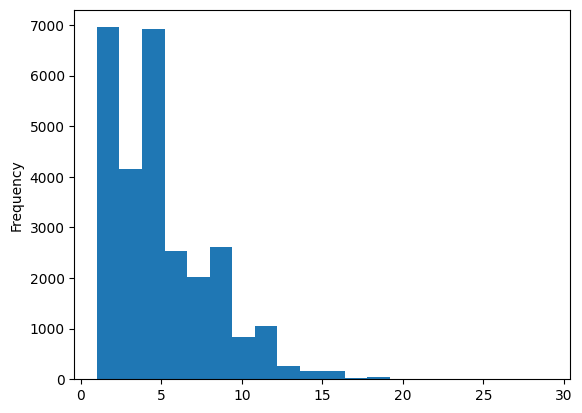

In [200]:
# Sanity check our event counts.
# Should have a min >= 0, 
# mostly small ints
# right-skewed (many low-count bins, few high ones) 
event_counts['count'].plot.hist(bins=20)

In [201]:
len(event_counts)

27735

In [202]:
def reindex_complete_6h_grid(
    event_counts: pd.DataFrame,
    *,
    neighborhoods: Sequence[str],
    start: str | pd.Timestamp,
    end: str | pd.Timestamp,  # exclusive end
    freq: str = "6H",
) -> pd.DataFrame:
    """
    Ensure every neighborhood has a complete 6-hour time grid in [start, end),
    filling missing intervals with count=0.

    Parameters
    ----------
    event_counts:
        DataFrame with columns: neighborhood, interval_start, count
    neighborhoods:
        Neighborhoods to include (and order to use).
    start, end:
        Time bounds: [start, end) (end is exclusive).
    freq:
        Frequency string, default "6H".

    Returns
    -------
    pd.DataFrame
        Columns: neighborhood, interval_start, count
        with complete grid and missing counts filled with 0.
    """
    required = {"neighborhood", "interval_start", "count"}
    missing = required - set(event_counts.columns)
    if missing:
        raise ValueError(f"event_counts missing required columns: {missing}")

    df = event_counts.copy()

    # Normalize dtypes
    df["interval_start"] = pd.to_datetime(df["interval_start"], errors="coerce")
    df["count"] = df["count"].fillna(0).astype("int64")

    # Build the complete 6-hour time index for the requested window
    start_ts = pd.Timestamp(start).floor(freq)
    end_ts = pd.Timestamp(end)

    full_range = pd.date_range(start=start_ts, end=end_ts, freq=freq)
    full_range = full_range[full_range < end_ts]  # enforce [start, end)

    # Build MultiIndex of all neighborhood × interval_start combos
    # Use Categorical so neighborhoods stay in your desired order
    neighborhoods_cat = pd.Categorical(neighborhoods, categories=list(neighborhoods), ordered=False)

    full_index = pd.MultiIndex.from_product(
        [neighborhoods_cat, full_range],
        names=["neighborhood", "interval_start"],
    )

    # Reindex onto the full grid and fill missing counts with 0
    out = (
        df.set_index(["neighborhood", "interval_start"])
          .reindex(full_index, fill_value=0)
          .reset_index()
          .sort_values(["neighborhood", "interval_start"], kind="stable")
          .reset_index(drop=True)
    )

    out["neighborhood"] = out["neighborhood"].astype("category")
    out["count"] = out["count"].astype("int64")

    return out

In [203]:
neighborhoods = ["Mission", "SoMa", "Tenderloin", "Nob Hill", "Ingleside"]

event_counts_full = reindex_complete_6h_grid(
    event_counts,
    neighborhoods=neighborhoods,
    start="2016-01-01",
    end="2020-01-01",   # exclusive
    freq="6h",
)

event_counts_full.head(5)

,neighborhood,interval_start,count
0,Mission,2016-01-01 00:00:00,10
1,Mission,2016-01-01 06:00:00,2
2,Mission,2016-01-01 12:00:00,1
3,Mission,2016-01-01 18:00:00,3
4,Mission,2016-01-02 00:00:00,4


# Feature Engineering

In [204]:
@dataclass(frozen=True)
class TimeFeatureConfig:
    """Config for cyclical encodings."""
    dow_period: int = 7
    hour_period: int = 24


def add_time_features(
    df: pd.DataFrame,
    *,
    ts_col: str = "interval_start",
    config: TimeFeatureConfig = TimeFeatureConfig(),
) -> pd.DataFrame:
    """
    Add basic datetime features + cyclical encodings derived from `ts_col`.

    Adds:
      - year, month, day, dow (0=Mon..6=Sun), hour (0/6/12/18)
      - dow_sin, dow_cos
      - hour_sin, hour_cos
    """
    if ts_col not in df.columns:
        raise ValueError(f"Missing required timestamp column: {ts_col}")

    out = df.copy()
    out[ts_col] = pd.to_datetime(out[ts_col], errors="coerce")

    # Basic parts
    out["year"] = out[ts_col].dt.year.astype("int32")
    out["month"] = out[ts_col].dt.month.astype("int8")
    out["day"] = out[ts_col].dt.day.astype("int8")
    out["dow"] = out[ts_col].dt.dayofweek.astype("int8")  # 0=Mon ... 6=Sun
    out["hour"] = out[ts_col].dt.hour.astype("int8")      # should be 0,6,12,18

    # Cyclical encodings
    # Convert to radians: 2π * value / period
    dow_rad = 2.0 * np.pi * (out["dow"].to_numpy() / config.dow_period)
    hour_rad = 2.0 * np.pi * (out["hour"].to_numpy() / config.hour_period)

    out["dow_sin"] = np.sin(dow_rad)
    out["dow_cos"] = np.cos(dow_rad)
    out["hour_sin"] = np.sin(hour_rad)
    out["hour_cos"] = np.cos(hour_rad)

    return out


In [205]:
# Add time features to our dataframe
# event_counts_full columns: neighborhood, interval_start, count
feat_df = add_time_features(event_counts_full)

feat_df[["neighborhood", "interval_start", "year", "month", "day", "dow", "hour", "dow_sin", "dow_cos", "hour_sin", "hour_cos", "count"]].head()


,neighborhood,interval_start,year,month,day,dow,hour,dow_sin,dow_cos,hour_sin,hour_cos,count
0,Mission,2016-01-01 00:00:00,2016,1,1,4,0,-0.433884,-0.900969,0.000000e+00,1.000000e+00,10
1,Mission,2016-01-01 06:00:00,2016,1,1,4,6,-0.433884,-0.900969,1.000000e+00,6.123234e-17,2
2,Mission,2016-01-01 12:00:00,2016,1,1,4,12,-0.433884,-0.900969,1.224647e-16,-1.000000e+00,1
3,Mission,2016-01-01 18:00:00,2016,1,1,4,18,-0.433884,-0.900969,-1.000000e+00,-1.836970e-16,3
4,Mission,2016-01-02 00:00:00,2016,1,2,5,0,-0.974928,-0.222521,0.000000e+00,1.000000e+00,4


# Preprocessing: ColumnTransformer (OHE Neighborhood + Scale Numeric)

In [206]:
def make_preprocessor(
    *,
    categorical_features: List[str],
    numeric_features: List[str],
    scale_numeric: bool = True,
    ohe_drop: Optional[str] = None,  # e.g. "first" or None
) -> ColumnTransformer:
    """
    Build a ColumnTransformer that:
      - OneHotEncodes categorical features (neighborhood)
      - Optionally scales numeric features (for linear models)
    """
    cat = OneHotEncoder(
        drop=ohe_drop,
        handle_unknown="ignore",
        sparse_output=False,  # sklearn >=1.2
    )

    num = StandardScaler() if scale_numeric else "passthrough"

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", cat, categorical_features),
            ("num", num, numeric_features),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return preprocessor

In [207]:
# Define feature columns
BASE_CATEGORICAL = ["neighborhood"]
BASE_NUMERIC = ["year", "month", "day", "dow_sin", "dow_cos", "hour_sin", "hour_cos"]
TARGET_COL = "count"

# Build Baseline Pipelines (Ridge + HGBR)

In [208]:
def make_ridge_pipeline(
    *,
    ohe_drop: Optional[str] = None,
    alpha: float = 1.0,
    random_state: int = 42,
) -> Pipeline:
    """
    Ridge baseline: OHE + StandardScaler + Ridge.
    """
    pre = make_preprocessor(
        categorical_features=BASE_CATEGORICAL,
        numeric_features=BASE_NUMERIC,
        scale_numeric=True,
        ohe_drop=ohe_drop,
    )

    model = Ridge(alpha=alpha, random_state=random_state)

    return Pipeline(steps=[
        ("preprocess", pre),
        ("model", model),
    ])

In [209]:
def make_hgbr_pipeline(
    *,
    ohe_drop: Optional[str] = None,
    random_state: int = 42,
) -> Pipeline:
    """
    Gradient boosting baseline: OHE + passthrough numeric (no scaling) + HGBR.
    """
    pre = make_preprocessor(
        categorical_features=BASE_CATEGORICAL,
        numeric_features=BASE_NUMERIC,
        scale_numeric=False,
        ohe_drop=ohe_drop,
    )

    model = HistGradientBoostingRegressor(random_state=random_state)

    return Pipeline(steps=[
        ("preprocess", pre),
        ("model", model),
    ])


In [210]:
# Prepary X / y 

# X / y
X = feat_df[BASE_CATEGORICAL + BASE_NUMERIC].copy()
y = feat_df[TARGET_COL].astype("int64")


In [211]:
# Sanity checks
# Check bins are only the expected hours
feat_df["hour"].value_counts().sort_index()

hour
0     7305
6     7305
12    7305
18    7305
Name: count, dtype: int64

In [212]:
# Check dow range
feat_df["dow"].min(), feat_df["dow"].max()

(np.int8(0), np.int8(6))

In [213]:
# Check no NA in features
X.isna().sum()

neighborhood    0
year            0
month           0
day             0
dow_sin         0
dow_cos         0
hour_sin        0
hour_cos        0
dtype: int64

# Store Variables

In [214]:
%store feat_df event_counts_full

Stored 'feat_df' (DataFrame)
Stored 'event_counts_full' (DataFrame)


In [215]:
# Retrieve all dataframes
# %store -r feat_df
%store -r feat_df event_counts_full
#%store -r events_counts_full

In [216]:
# Define feature columns
BASE_CATEGORICAL = ["neighborhood"]
BASE_NUMERIC = ["year", "month", "day", "dow_sin", "dow_cos", "hour_sin", "hour_cos"]
TARGET_COL = "count"

In [13]:
dir()

['BASE_CATEGORICAL',
 'BASE_NUMERIC',
 'ColumnTransformer',
 'DatePicker',
 'Dropdown',
 'DummyRegressor',
 'HBox',
 'HTML',
 'HistGradientBoostingRegressor',
 'Image',
 'In',
 'Iterable',
 'JSON',
 'Label',
 'Layout',
 'List',
 'Map',
 'Marker',
 'MarkerCluster',
 'MplPath',
 'OneHotEncoder',
 'Optional',
 'Out',
 'Output',
 'Path',
 'Pipeline',
 'ProfileReport',
 'PurePath',
 'Ridge',
 'Sequence',
 'StandardScaler',
 'TARGET_COL',
 'TEST_FRACTION',
 'Tuple',
 'VBox',
 '_',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__session__',
 '__spec__',
 '_dh',
 '_i',
 '_i1',
 '_i10',
 '_i11',
 '_i12',
 '_i13',
 '_i2',
 '_i3',
 '_i4',
 '_i5',
 '_i6',
 '_i7',
 '_i8',
 '_i9',
 '_ih',
 '_ii',
 '_iii',
 '_oh',
 'annotations',
 'basemaps',
 'copy',
 'dataclass',
 'datetime',
 'display',
 'duckdb',
 'event_counts_full',
 'exit',
 'feat_df',
 'get_ipython',
 'go',
 'logging',
 'max_error',
 'mean_absolute_error',
 'mean_squared_error',
 'mt

In [14]:
to_delete = [
 'air_duels',
 'annotations',
 'basemaps',
 'calcareers_resume',
 'copy',
 'dataclass',
 'datetime',
 'display',
 'duckdb',
 'duels',
 'efficency_df',
 'efficiency_df',
 'euro_2024_matches',
 'euro_2024_wingers',
 'exit',
 'final_third',
 'final_third_passes',
 'gakp',
 'get_ipython',
 'go',
 'logging',
 'max_error',
 'mean_absolute_error',
 'mean_squared_error',
 'minutes',
 'mticker',
 'my_inferred_feature_cols',
 'nico_p90_results',
 'nico_williams_events',
 'np',
 'npxg',
 'nw_pass_length',
 'open',
 'os',
 'params',
 'pd',
 'percentiles',
 'pio',
 'players_df',
 'plt',
 'pq',
 'px',
 'quit',
 'random',
 'requests',
 'salah_row',
 'smart_passes',
 'sns',
 'spain_lineups_df',
 'spain_matches',
 'spain_matches_info',
 'summary',
 'summary_per_90',
 'tqdm',
 'train',
 'values',
 'volume_per_90_df',
 'winger_ids_df']

In [15]:
# Source - https://stackoverflow.com/a/64594787
# Posted by go2nirvana
# Retrieved 2026-01-11, License - CC BY-SA 4.0

# to_delete = ['i', 'myvar']
# for _var in to_delete:
#     if _var in locals() or _var in globals():
#         exec(f'del {_var}')


In [3]:
feat_df.head(1)

,neighborhood,interval_start,count,year,month,day,dow,hour,dow_sin,dow_cos,hour_sin,hour_cos
0,Mission,2016-01-01,10,2016,1,1,4,0,-0.433884,-0.900969,0.0,1.0


# Time Aware Test/Train Split

At this point we have:

* event_counts_full
    * columns: neighborhood, interval_start, count
* feat_df = add_time_features(event_counts_full)
* Feature columns already defined
* Target column: count

We will **not**:

* stratify
* shuffle
* group by neighborhood
* use sklearn’s train_test_split

We will do this manually.
1. Sort everything by time
2. Take earliest **85%** of timestamps --> training
3. Take latest **15%** of timestamps --> test
4. Test data must be _strictly later in time_ that training data.

In [217]:
# Sort by time
feat_df = feat_df.sort_values("interval_start").reset_index(drop=True)

In [218]:
# Compute the split point by index
TEST_FRACTION = 0.15

n_samples = len(feat_df)
split_idx = int(n_samples * (1 - TEST_FRACTION))


In [219]:
# Split X and y

X = feat_df[BASE_CATEGORICAL + BASE_NUMERIC]
y = feat_df["count"]

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

In [220]:
X_train.columns

Index(['neighborhood', 'year', 'month', 'day', 'dow_sin', 'dow_cos',
       'hour_sin', 'hour_cos'],
      dtype='object')

In [221]:
# Sanity check time ordering
feat_df["interval_start"].max(), feat_df["interval_start"].min()

(Timestamp('2019-12-31 18:00:00'), Timestamp('2016-01-01 00:00:00'))

In [222]:
# Neighborhood presence. All neighborhoods should be present.
X_train["neighborhood"].value_counts()
X_test["neighborhood"].value_counts()

neighborhood
Mission       877
SoMa          877
Ingleside     877
Tenderloin    876
Nob Hill      876
Name: count, dtype: int64

We do not split per neighborhood, as the model learns neighborhoods as a feature. We want temporal generalization, not neighborhood isolation.

# Why we need DummyRegressor

We predicting counts, per 6-hour bin, per neighborhood. Counts have:
* Central tendency (average level)
* Big variance by neighborhood and time

Mode can look good, but just basically guess something near average. `DummyRegressor` gives performance of that exact behavior.

* If Ridge/HBR barely beats DummyRegressor:
    * Features/model are not learning much signal, or we are over-regularized, or you have leakage elsewhere.
* If Ridge / HGBR clearly beats DummyRegressor:
    * Model is extracting useful predictive structure.
 
* RMSE / MAE
    * Set the "floor." Your model must reduce RMSE/MAE relative to dummy, or it not worth it.
 
Mean is the correct dummy since we want to "predict the typical count."

We must fit `DummyRegressor` on TRAIN only to prevent leakage. Fit on `y_train` and evaluate on `y_test`.

The "precision" takeaway is that `DummyRegressor` is a control group. 
* **Control**: predict the mean always (DummyRegressor)
* **Treatment**: your ML model (Ridge / HGBR)

In [12]:
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)          # X_train is ignored, but required by API
y_pred_train = dummy.predict(X_train)
y_pred_test  = dummy.predict(X_test)

In [13]:
def regression_metrics(
    y_true: np.ndarray | pd.Series,
    y_pred: np.ndarray,
) -> dict[str, float]:
    """
    Compute regression metrics used in the assignment.
    """
    return {
        "RMSE": mean_squared_error(y_true, y_pred, multioutput='raw_values'),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MaxError": max_error(y_true, y_pred),
    }


In [14]:
mean_squared_error?

Signature:
mean_squared_error(
    y_true,
    y_pred,
    *,
    sample_weight=None,
    multioutput='uniform_average',
)
Docstring:
Mean squared error regression loss.

Read more in the :ref:`User Guide <mean_squared_error>`.

Parameters
----------
y_true : array-like of shape (n_samples,) or (n_samples, n_outputs)
    Ground truth (correct) target values.

y_pred : array-like of shape (n_samples,) or (n_samples, n_outputs)
    Estimated target values.

sample_weight : array-like of shape (n_samples,), default=None
    Sample weights.

multioutput : {'raw_values', 'uniform_average'} or array-like of shape             (n_outputs,), default='uniform_average'
    Defines aggregating of multiple output values.
    Array-like value defines weights used to average errors.

    'raw_values' :
        Returns a full set of errors in case of multioutput input.

    'uniform_average' :
        Errors of all outputs are averaged with uniform weight.

Returns
-------
loss : float or array of flo

In [15]:
# Evaluate metrics
dummy_train_metrics = regression_metrics(y_train, y_pred_train)
dummy_test_metrics  = regression_metrics(y_test, y_pred_test)

dummy_train_metrics, dummy_test_metrics


({'RMSE': array([10.06294864]),
  'MAE': 2.517600949761475,
  'MaxError': 19.437250875709626},
 {'RMSE': array([13.05715407]),
  'MAE': 2.7677905804848293,
  'MaxError': 24.437250875709626})

In [16]:
# Sanity check what dummy predicts
dummy.constant_

array([[4.56274912]])

In [17]:
# ...`dummy.constant_` should equal y_train.mean()
y_train.mean()

np.float64(4.562749124290373)

# Ridge Regressor

In [18]:
# ----------------------------
# Ridge pipeline
# ----------------------------
# Preprocessor: OHE for neighborhood, scale numeric for Ridge
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", drop=None, sparse_output=False), BASE_CATEGORICAL),
        ("num", StandardScaler(), BASE_NUMERIC),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

ridge = Ridge(alpha=1.0, random_state=42)

ridge_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", ridge),
])


# ----------------------------
# Fit + predict
# ----------------------------
ridge_pipe.fit(X_train, y_train)

y_train_pred_ridge = ridge_pipe.predict(X_train)
y_test_pred_ridge  = ridge_pipe.predict(X_test)


# ----------------------------
# Evaluate
# ----------------------------
ridge_train_metrics = regression_metrics(y_train, y_train_pred_ridge)
ridge_test_metrics  = regression_metrics(y_test, y_test_pred_ridge)

ridge_train_metrics, ridge_test_metrics


({'RMSE': array([5.45464911]),
  'MAE': 1.8017087150401707,
  'MaxError': 15.816258424819345},
 {'RMSE': array([6.5965887]),
  'MAE': 1.8889425206844308,
  'MaxError': 20.721761152185397})

In [19]:
# Assumes you already computed these from the DummyRegressor step:
# dummy_train_metrics, dummy_test_metrics

results = pd.DataFrame(
    [
        {
            "Model": "DummyRegressor (mean)",
            "Train RMSE": dummy_train_metrics["RMSE"],
            "Test RMSE": dummy_test_metrics["RMSE"],
            "Train MAE": dummy_train_metrics["MAE"],
            "Test MAE": dummy_test_metrics["MAE"],
            "Train MaxError": dummy_train_metrics["MaxError"],
            "Test MaxError": dummy_test_metrics["MaxError"],
        },
        {
            "Model": "Ridge",
            "Train RMSE": ridge_train_metrics["RMSE"],
            "Test RMSE": ridge_test_metrics["RMSE"],
            "Train MAE": ridge_train_metrics["MAE"],
            "Test MAE": ridge_test_metrics["MAE"],
            "Train MaxError": ridge_train_metrics["MaxError"],
            "Test MaxError": ridge_test_metrics["MaxError"],
        },
    ]
).set_index("Model")

results


,Train RMSE,Test RMSE,Train MAE,Test MAE,Train MaxError,Test MaxError
Model,,,,,,
DummyRegressor (mean),[10.062948644755544],[13.057154069017654],2.517601,2.767791,19.437251,24.437251
Ridge,[5.454649114661952],[6.596588700064782],1.801709,1.888943,15.816258,20.721761


In [20]:
# Reconstruct the rows corresponding to X_test, including interval_start
# This works even if X_test does not contain interval_start.
test_rows = feat_df.loc[X_test.index, ["interval_start", "neighborhood", "count"]].copy()

# Attach predictions with explicit index alignment
test_rows["pred_ridge"] = pd.Series(np.asarray(y_test_pred_ridge), index=X_test.index)

#  Show a few chronological examples
test_rows = test_rows.sort_values("interval_start")
test_rows.head(15)

,interval_start,neighborhood,count,pred_ridge
24837,2019-05-26 18:00:00,Ingleside,3,2.257002
24838,2019-05-26 18:00:00,Mission,4,3.780552
24839,2019-05-26 18:00:00,SoMa,11,6.628379
24840,2019-05-27 00:00:00,Tenderloin,7,4.940664
24841,2019-05-27 00:00:00,Mission,2,1.840398
24842,2019-05-27 00:00:00,SoMa,2,4.688224
24843,2019-05-27 00:00:00,Ingleside,0,0.316848
24844,2019-05-27 00:00:00,Nob Hill,5,2.013113
24845,2019-05-27 06:00:00,SoMa,12,6.140689
24846,2019-05-27 06:00:00,Tenderloin,4,6.393128


In [21]:
y_test_pred_ridge

array([2.2570017 , 3.78055243, 6.62837851, ..., 6.50873795, 3.66091187,
       2.13736114])

In [22]:
def build_pred_frame(
    feat_df: pd.DataFrame,
    X_index: pd.Index,
    y_true: pd.Series,
    y_pred: np.ndarray | pd.Series,
    *,
    y_col: str = "count",
    pred_col: str = "pred",
) -> pd.DataFrame:
    """
    Return a tidy frame with interval_start, neighborhood, y_true, y_pred aligned by index.
    """
    out = feat_df.loc[X_index, ["interval_start", "neighborhood", y_col]].copy()
    out = out.rename(columns={y_col: "y_true"})
    out[pred_col] = pd.Series(np.asarray(y_pred), index=X_index)
    return out.sort_values(["neighborhood", "interval_start"], kind="stable").reset_index(drop=True)


test_preds = build_pred_frame(
    feat_df=feat_df,
    X_index=X_test.index,
    y_true=y_test,
    y_pred=y_test_pred_ridge,
    pred_col="y_pred",
)

# Last ~30 intervals PER neighborhood
last30_per_neighborhood = (
    test_preds.sort_values("interval_start")
              .groupby("neighborhood", as_index=False, observed=True)
              .tail(30)
              .sort_values(["neighborhood", "interval_start"])
)

last30_per_neighborhood


,interval_start,neighborhood,y_true,y_pred
847,2019-12-24 12:00:00,Mission,5,5.198694
848,2019-12-24 18:00:00,Mission,3,3.746229
849,2019-12-25 00:00:00,Mission,1,1.916051
850,2019-12-25 06:00:00,Mission,4,3.368515
851,2019-12-25 12:00:00,Mission,5,5.256979
...,...,...,...,...
4378,2019-12-30 18:00:00,Ingleside,1,2.124712
4379,2019-12-31 00:00:00,Ingleside,1,0.248897
4380,2019-12-31 06:00:00,Ingleside,3,1.701362
4381,2019-12-31 12:00:00,Ingleside,3,3.589826


## Scatterplot Actual vs. Predicted

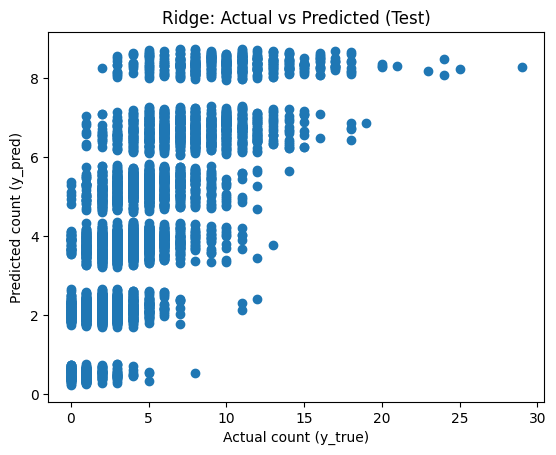

In [23]:
plt.figure()
plt.scatter(test_preds["y_true"], test_preds["y_pred"])
plt.xlabel("Actual count (y_true)")
plt.ylabel("Predicted count (y_pred)")
plt.title("Ridge: Actual vs Predicted (Test)")
plt.show()


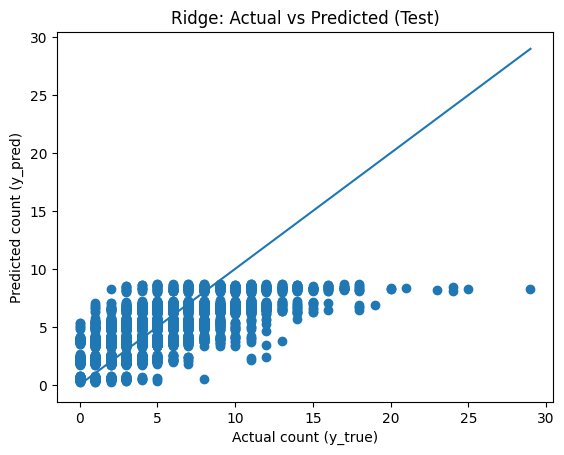

In [24]:
plt.figure()
plt.scatter(test_preds["y_true"], test_preds["y_pred"])
m = min(test_preds["y_true"].min(), test_preds["y_pred"].min())
M = max(test_preds["y_true"].max(), test_preds["y_pred"].max())
plt.plot([m, M], [m, M])  # diagonal reference
plt.xlabel("Actual count (y_true)")
plt.ylabel("Predicted count (y_pred)")
plt.title("Ridge: Actual vs Predicted (Test)")
plt.show()


## Residuals Over Time (Test Set)

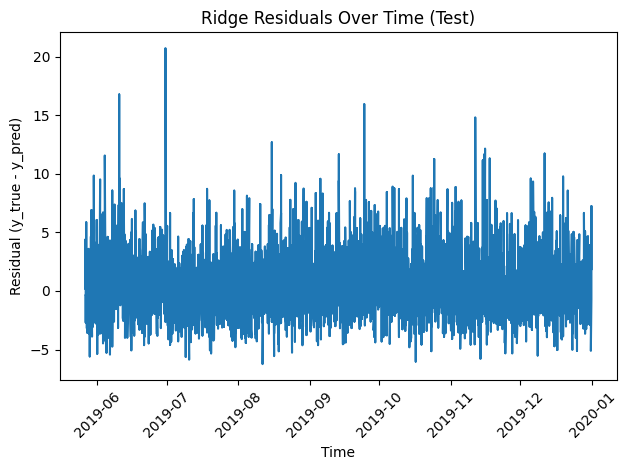

In [25]:
test_preds_time = test_preds.sort_values("interval_start").copy()
test_preds_time["residual"] = test_preds_time["y_true"] - test_preds_time["y_pred"]

plt.figure()
plt.plot(test_preds_time["interval_start"], test_preds_time["residual"])
plt.xlabel("Time")
plt.ylabel("Residual (y_true - y_pred)")
plt.title("Ridge Residuals Over Time (Test)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


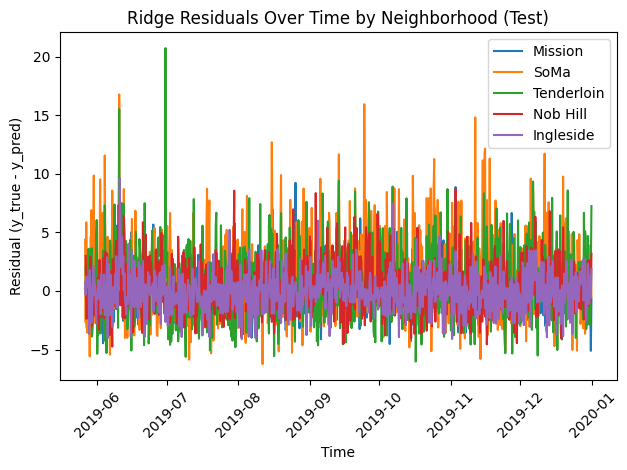

In [26]:
# Per neighborhood
plt.figure()
for nbhd, g in test_preds_time.groupby("neighborhood", observed=True):
    plt.plot(g["interval_start"], g["residual"], label=str(nbhd))
plt.xlabel("Time")
plt.ylabel("Residual (y_true - y_pred)")
plt.title("Ridge Residuals Over Time by Neighborhood (Test)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


## Over/Underfitting Check

In [27]:
rows = [
    {
        "Model": "Ridge",
        "Train RMSE": ridge_train_metrics["RMSE"],
        "Test RMSE": ridge_test_metrics["RMSE"],
        "Train MAE": ridge_train_metrics["MAE"],
        "Test MAE": ridge_test_metrics["MAE"],
        "Train MaxError": ridge_train_metrics["MaxError"],
        "Test MaxError": ridge_test_metrics["MaxError"],
    }
]

# Add dummy row if you have it
if "dummy_train_metrics" in globals() and "dummy_test_metrics" in globals():
    rows.insert(0, {
        "Model": "DummyRegressor (mean)",
        "Train RMSE": dummy_train_metrics["RMSE"],
        "Test RMSE": dummy_test_metrics["RMSE"],
        "Train MAE": dummy_train_metrics["MAE"],
        "Test MAE": dummy_test_metrics["MAE"],
        "Train MaxError": dummy_train_metrics["MaxError"],
        "Test MaxError": dummy_test_metrics["MaxError"],
    })

pd.DataFrame(rows).set_index("Model")


,Train RMSE,Test RMSE,Train MAE,Test MAE,Train MaxError,Test MaxError
Model,,,,,,
DummyRegressor (mean),[10.062948644755544],[13.057154069017654],2.517601,2.767791,19.437251,24.437251
Ridge,[5.454649114661952],[6.596588700064782],1.801709,1.888943,15.816258,20.721761


Interpreting results

* Dummy Test RMSE = 13.06, Ridge Test RMSE = 6.60 --> 50% reduction in RMSE
* Dummy Test MAE = 2.77, Ridge Test MAE = 1.89 --> 32% reduction in typical absolute error. Ridge is learning structure
* Overfitting = (Test RMSE - Train RMSE )/ Train RMSE --> 1.15 / 5.45 ~ 21%.
* MAE ~ 1.9 --> On average, we are off by ~2 events per 6-hour window.
    * If counts are 1-3, this is large
    * If counts are 5-15, this is moderat
    * If counts are 20-40, this is small
* Large MaxError indicates there is a bin where we missed by ~ 21 events.
    * Linear models smooth
    * Emergency spikes are nonlinear
    * Rare surges dominate max error.
    * Why assignment suggests using "more powerful ML models."  

In [28]:
feat_df['count'].describe()

count    29220.000000
mean         4.635010
std          3.241484
min          0.000000
25%          2.000000
50%          4.000000
75%          6.000000
max         29.000000
Name: count, dtype: float64

## Test Importance

In [29]:
from city_events_ml.io import TargetSpec, build_target_table
from city_events_ml.features import add_time_features
from city_events_ml.pipelines import (
    FeatureSpec,
    make_dummy_pipeline,
    make_ridge_pipeline,
    make_hgbr_pipeline,
    make_poisson_pipeline,
)
from city_events_ml.evaluation import (
    MetricsStore,
    evaluate_model,
    get_feature_names,
    linear_feature_importance,
    hgbr_permutation_importance,
    plot_feature_importance,
)
from city_events_ml.serialization import save_model_skops

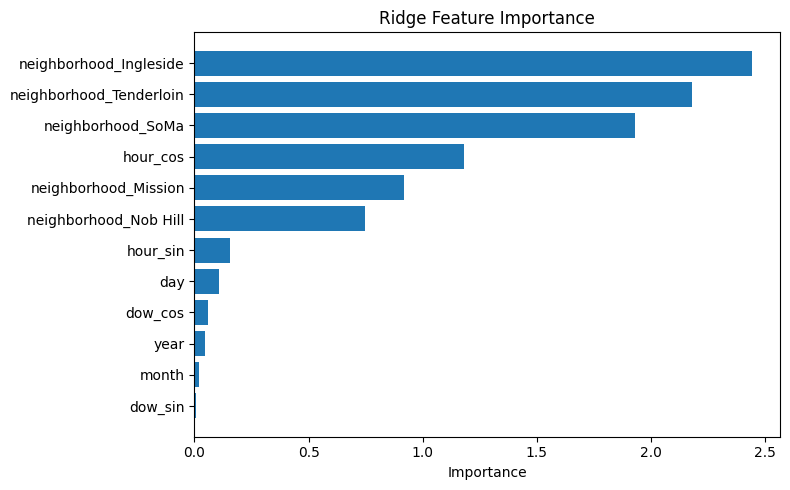

In [30]:
ridge_imp = linear_feature_importance(ridge_pipe)
plot_feature_importance(ridge_imp, "importance", "Ridge Feature Importance")

# HistGradientBoosting Regressor

In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, max_error
from sklearn.inspection import permutation_importance

In [41]:
# ----------------------------
# Metrics helpers
# ----------------------------
def rmse(y_true: np.ndarray | pd.Series, y_pred: np.ndarray) -> float:
    return mean_squared_error(y_true, y_pred, )

def mae(y_true: np.ndarray | pd.Series, y_pred: np.ndarray) -> float:
    return mean_absolute_error(y_true, y_pred)

def maxerr(y_true: np.ndarray | pd.Series, y_pred: np.ndarray) -> float:
    return max_error(y_true, y_pred)

def evaluate_regression(y_true: pd.Series, y_pred: np.ndarray) -> dict[str, float]:
    return {"RMSE": rmse(y_true, y_pred), "MAE": mae(y_true, y_pred), "MaxError": maxerr(y_true, y_pred)}



In [42]:
preprocess_hgbr = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", drop=None, sparse_output=False), BASE_CATEGORICAL),
        ("num", "passthrough", BASE_NUMERIC),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

hgbr = HistGradientBoostingRegressor(
    random_state=42,
    loss="squared_error",
)

hgbr_pipe = Pipeline(steps=[
    ("preprocess", preprocess_hgbr),
    ("model", hgbr),
])


# ----------------------------
# Time-series CV setup
# ----------------------------
tscv = TimeSeriesSplit(n_splits=5)


# ----------------------------
# Fast randomized hyperparam search
# ----------------------------
param_distributions = {
    "model__learning_rate": [0.03, 0.05, 0.08, 0.1, 0.15],
    "model__max_depth": [None, 3, 5, 7, 9],
    "model__max_leaf_nodes": [15, 31, 63, 127],
    "model__min_samples_leaf": [10, 20, 50, 100],
    "model__l2_regularization": [0.0, 0.01, 0.1, 1.0],
}

search = RandomizedSearchCV(
    estimator=hgbr_pipe,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="neg_root_mean_squared_error",  # RMSE (lower is better)
    cv=tscv,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

search.fit(X_train, y_train)

best_hgbr_pipe = search.best_estimator_
best_params = search.best_params_
best_cv_rmse = -search.best_score_

best_params, best_cv_rmse

Fitting 5 folds for each of 20 candidates, totalling 100 fits


({'model__min_samples_leaf': 20,
  'model__max_leaf_nodes': 15,
  'model__max_depth': 9,
  'model__learning_rate': 0.03,
  'model__l2_regularization': 0.0},
 np.float64(2.270299018266662))

In [43]:
# ----------------------------
# CV summary: mean ± std for RMSE + MAE
# ----------------------------
cv_results = pd.DataFrame(search.cv_results_)

# RMSE from scoring (neg_root_mean_squared_error)
rmse_mean = -cv_results.loc[cv_results["rank_test_score"] == 1, "mean_test_score"].iloc[0]
rmse_std  =  cv_results.loc[cv_results["rank_test_score"] == 1, "std_test_score"].iloc[0]

# Compute MAE across folds using cross-val predictions is more work;
# simplest: refit best model per fold manually.
def cv_mae_for_best_model(
    model: Pipeline,
    X: pd.DataFrame,
    y: pd.Series,
    splitter: TimeSeriesSplit,
) -> tuple[float, float]:
    maes: list[float] = []
    for train_idx, val_idx in splitter.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        m = model
        m.fit(X_tr, y_tr)
        pred = m.predict(X_val)
        maes.append(mean_absolute_error(y_val, pred))
    return float(np.mean(maes)), float(np.std(maes))

best_model_for_cv = best_hgbr_pipe
mae_mean, mae_std = cv_mae_for_best_model(best_model_for_cv, X_train, y_train, tscv)

cv_summary = pd.DataFrame(
    {
        "Metric": ["RMSE", "MAE"],
        "CV Mean": [rmse_mean, mae_mean],
        "CV Std": [rmse_std, mae_std],
    }
)

cv_summary


,Metric,CV Mean,CV Std
0,RMSE,2.270299,0.035095
1,MAE,1.749381,0.014529


In [44]:
# ----------------------------
# Final fit on full train, eval on train/test
# ----------------------------
best_hgbr_pipe.fit(X_train, y_train)

y_train_pred_hgbr = best_hgbr_pipe.predict(X_train)
y_test_pred_hgbr  = best_hgbr_pipe.predict(X_test)

hgbr_train_metrics = evaluate_regression(y_train, y_train_pred_hgbr)
hgbr_test_metrics  = evaluate_regression(y_test, y_test_pred_hgbr)

hgbr_train_metrics, hgbr_test_metrics


({'RMSE': 4.975591474617809,
  'MAE': 1.7239821568202318,
  'MaxError': 16.180178137545337},
 {'RMSE': 6.23443691310528,
  'MAE': 1.8386898634747633,
  'MaxError': 21.13717840190774})

In [45]:
# ----------------------------
# Add to your comparison table (Dummy / Ridge / HGBR)
# Assumes you already have dummy_* and ridge_* metrics from Phase 4.
# ----------------------------
rows = []

if "dummy_train_metrics" in globals() and "dummy_test_metrics" in globals():
    rows.append({
        "Model": "DummyRegressor (mean)",
        "Train RMSE": dummy_train_metrics["RMSE"],
        "Test RMSE": dummy_test_metrics["RMSE"],
        "Train MAE": dummy_train_metrics["MAE"],
        "Test MAE": dummy_test_metrics["MAE"],
        "Train MaxError": dummy_train_metrics["MaxError"],
        "Test MaxError": dummy_test_metrics["MaxError"],
    })

if "ridge_train_metrics" in globals() and "ridge_test_metrics" in globals():
    rows.append({
        "Model": "Ridge",
        "Train RMSE": ridge_train_metrics["RMSE"],
        "Test RMSE": ridge_test_metrics["RMSE"],
        "Train MAE": ridge_train_metrics["MAE"],
        "Test MAE": ridge_test_metrics["MAE"],
        "Train MaxError": ridge_train_metrics["MaxError"],
        "Test MaxError": ridge_test_metrics["MaxError"],
    })

rows.append({
    "Model": "HistGradientBoostingRegressor",
    "Train RMSE": hgbr_train_metrics["RMSE"],
    "Test RMSE": hgbr_test_metrics["RMSE"],
    "Train MAE": hgbr_train_metrics["MAE"],
    "Test MAE": hgbr_test_metrics["MAE"],
    "Train MaxError": hgbr_train_metrics["MaxError"],
    "Test MaxError": hgbr_test_metrics["MaxError"],
})

results_all = pd.DataFrame(rows).set_index("Model")
results_all


,Train RMSE,Test RMSE,Train MAE,Test MAE,Train MaxError,Test MaxError
Model,,,,,,
DummyRegressor (mean),[10.062948644755542],[13.057154069017656],2.517601,2.767791,19.437251,24.437251
Ridge,[5.454649114661952],[6.596588700064782],1.801709,1.888943,15.816258,20.721761
HistGradientBoostingRegressor,4.975591,6.234437,1.723982,1.838690,16.180178,21.137178


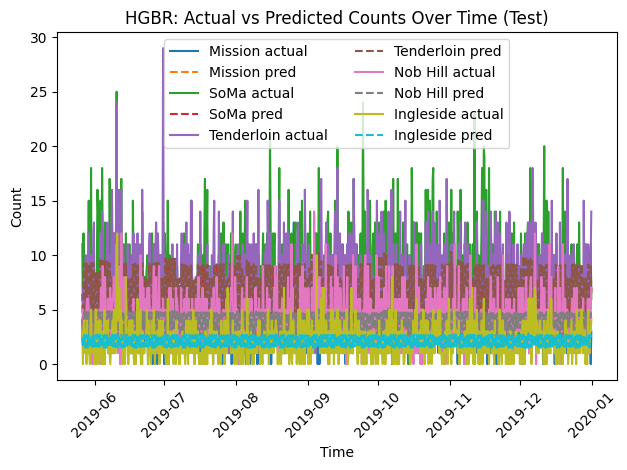

In [46]:
# ----------------------------
# Plots: Predictions vs Actual over time (test)
# Robust alignment using feat_df + X_test.index
# ----------------------------
import matplotlib.pyplot as plt

test_plot_df = feat_df.loc[X_test.index, ["interval_start", "neighborhood", "count"]].copy()
test_plot_df["pred_hgbr"] = pd.Series(np.asarray(y_test_pred_hgbr), index=X_test.index)
test_plot_df = test_plot_df.sort_values(["neighborhood", "interval_start"])

# Plot per neighborhood (time series)
plt.figure()
for nbhd, g in test_plot_df.groupby("neighborhood", observed=True):
    # show actual and predicted as lines (can be busy but acceptable for baseline)
    plt.plot(g["interval_start"], g["count"], label=f"{nbhd} actual")
    plt.plot(g["interval_start"], g["pred_hgbr"], label=f"{nbhd} pred", linestyle="--")
plt.xlabel("Time")
plt.ylabel("Count")
plt.title("HGBR: Actual vs Predicted Counts Over Time (Test)")
plt.xticks(rotation=45)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


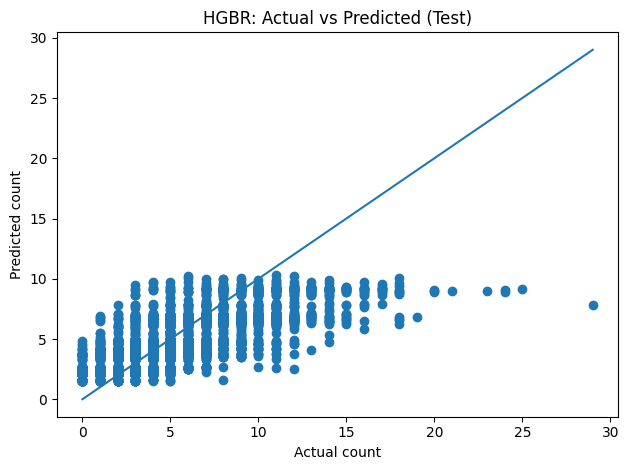

In [47]:
# ----------------------------
# Plots: Combined scatter y_true vs y_pred (test)
# ----------------------------
plt.figure()
plt.scatter(test_plot_df["count"], test_plot_df["pred_hgbr"])
m = min(test_plot_df["count"].min(), test_plot_df["pred_hgbr"].min())
M = max(test_plot_df["count"].max(), test_plot_df["pred_hgbr"].max())
plt.plot([m, M], [m, M])
plt.xlabel("Actual count")
plt.ylabel("Predicted count")
plt.title("HGBR: Actual vs Predicted (Test)")
plt.tight_layout()
plt.show()


In [48]:
# ----------------------------
# Permutation importance (on test set)
# NOTE: requires feature names; we can get them from the preprocessor.
# ----------------------------
# Get transformed feature names
feature_names = best_hgbr_pipe.named_steps["preprocess"].get_feature_names_out()

# These are the columns permutation_importance is permuting
input_feature_names = list(X_test.columns)

# Compute permutation importance on test set
perm = permutation_importance(
    best_hgbr_pipe,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring="neg_root_mean_squared_error",
)

importances = pd.DataFrame(
    {
        "feature": input_feature_names,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }
).sort_values("importance_mean", ascending=False)

importances.head(15)


,feature,importance_mean,importance_std
0,neighborhood,1.282866,0.017168
7,hour_cos,0.651734,0.011926
4,dow_sin,0.051444,0.004718
6,hour_sin,0.011955,0.001450
5,dow_cos,0.004290,0.001727
2,month,0.000471,0.000626
1,year,0.000000,0.000000
3,day,-0.000800,0.001725


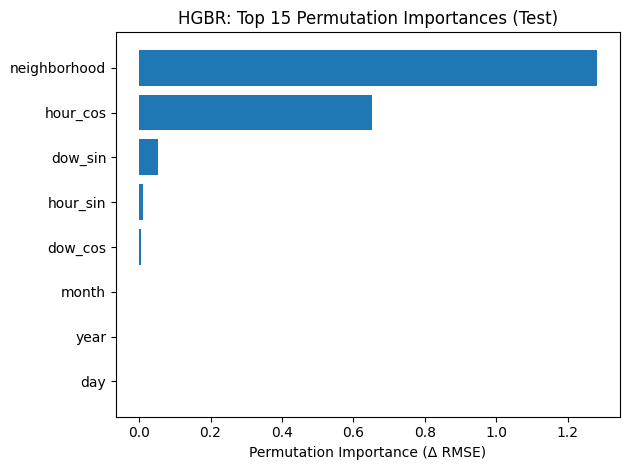

In [49]:
# Quick bar plot of top-k importances (optional)
top_k = 15
top = importances.head(top_k)

plt.figure()
plt.barh(top["feature"][::-1], top["importance_mean"][::-1])
plt.xlabel("Permutation Importance (Δ RMSE)")
plt.title(f"HGBR: Top {top_k} Permutation Importances (Test)")
plt.tight_layout()
plt.show()


* TimeSeriesSplit assumes rows are already time-ordered. If you created `X_train` from a sorted `feat_df`, you are fine.
* The MAE CV summary is computed by manual fold loop (simple + correct).
* Permutation importance can be slow; start with `n_repeats=5` if needed.

In [50]:
len(feature_names)

12

# Poisson Regressor

The mean of **4.6** and median of **4** indicates we can count processes with many low values.

Poisson regression often:
* Improves calibration for low counts (0–3)
* Handles zeros better
* Gives more realistic predictions than Ridge
* Does NOT necessarily fix extreme spikes (that’s nonlinear territory)

## Build Poisson Pipeline

In [51]:
from sklearn.linear_model import PoissonRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


preprocess_poisson = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", drop=None, sparse_output=False), BASE_CATEGORICAL),
        ("num", StandardScaler(), BASE_NUMERIC),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

poisson = PoissonRegressor(
    alpha=1.0,        # regularization (like Ridge)
    max_iter=1000,
)

poisson_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess_poisson),
        ("model", poisson),
    ]
)


In [52]:
# Fit and predict
poisson_pipe.fit(X_train, y_train)

y_train_pred_pois = poisson_pipe.predict(X_train)
y_test_pred_pois  = poisson_pipe.predict(X_test)

In [53]:
y_test_pred_pois.min()  # Should be >=0

np.float64(2.390625213062019)

## Evaluate with metrics helpers

In [54]:
poisson_train_metrics = regression_metrics(y_train, y_train_pred_pois)
poisson_test_metrics  = regression_metrics(y_test, y_test_pred_pois)

poisson_train_metrics, poisson_test_metrics

({'RMSE': array([6.2502402]),
  'MAE': 1.9407243436286024,
  'MaxError': 16.878520366463466},
 {'RMSE': array([8.15638645]),
  'MAE': 2.1261133880468135,
  'MaxError': 21.75378751935216})

In [55]:
rows.append({
    "Model": "PoissonRegressor",
    "Train RMSE": poisson_train_metrics["RMSE"],
    "Test RMSE": poisson_test_metrics["RMSE"],
    "Train MAE": poisson_train_metrics["MAE"],
    "Test MAE": poisson_test_metrics["MAE"],
    "Train MaxError": poisson_train_metrics["MaxError"],
    "Test MaxError": poisson_test_metrics["MaxError"],
})

results_all = pd.DataFrame(rows).set_index("Model")
results_all


,Train RMSE,Test RMSE,Train MAE,Test MAE,Train MaxError,Test MaxError
Model,,,,,,
DummyRegressor (mean),[10.062948644755542],[13.057154069017656],2.517601,2.767791,19.437251,24.437251
Ridge,[5.454649114661952],[6.596588700064782],1.801709,1.888943,15.816258,20.721761
HistGradientBoostingRegressor,4.975591,6.234437,1.723982,1.838690,16.180178,21.137178
PoissonRegressor,[6.250240201035183],[8.156386450494447],1.940724,2.126113,16.878520,21.753788


Poisson regression works best when:

* Counts are generated by a single underlying rate
* Variance is roughly proportional to the mean
* Effects are multiplicative but linear in log-space
* Interactions are weak or unnecessary

In plain English:

> “There is a smooth baseline rate, nudged up or down by features.”

This is a mismatch with our current data:

* Median = 4
* 75% ≤ 6
* Max = 29
* Rare, sharp spikes
* Strong neighborhood effects
* Time-of-day × neighborhood interactions
* Tenderloin behaves qualitatively differently

This is not a single smooth rate process.

It’s closer to:

> “Most of the time things are calm, but occasionally conditions align and everything jumps.”

That violates Poisson’s core assumption.

Ridge regression:

* Minimizes squared error directly
* Can “cheat” by predicting fractional values
* Handles variance flexibly
* Optimized for RMSE/MAE (your metrics)

Poisson regression:

* Optimizes log-likelihood, not RMSE
* Cares more about relative error at low counts
* Is conservative around spikes
* Penalizes overestimation differently than underestimation

# Test Package Installation

## Imports

In [1]:
from importlib import reload
import city_events_ml
reload(city_events_ml)

from city_events_ml.io import TargetSpec, build_target_table
from city_events_ml.features import add_time_features
from city_events_ml.pipelines import FeatureSpec, make_ridge_pipeline, make_hgbr_pipeline, make_poisson_pipeline
from city_events_ml.evaluation import MetricsStore, evaluate_model

## Load Dataset

In [4]:
# Manually set dir if things go awry
os.chdir('C:\\Users\\lover\\Documents\\GitHub\\predicting-safety-events-US-cities-base')

DATA_PATH = None

# Get current path
cwd = PurePath(Path.cwd())

# Use conditional to ensure we do not traverse to higher level dir.
if not DATA_PATH:
    # Change current working directory from `notebooks` directory to one level above.
    os.chdir('..')    
    
    # Construct path to archive location
    DATA_PATH = cwd / 'data'

# Confirm location where data files are stored.
logging.info(str(DATA_PATH))

2026-01-12 00:24:09,740 [INFO] C:\Users\lover\Documents\GitHub\predicting-safety-events-US-cities-base\data


In [5]:
# Load parquet file into dataframe
sf_dataframe = pd.read_parquet(DATA_PATH / 'safety-SanFrancisco-2.parquet')
sf_dataframe.head(1)

,requestId,dataSubtype,dateTime,category,subcategory,status,address,latitude,longitude,source,neighborhood
0,1,911_Fire,2018-10-02 11:54:01,Potentially Life-Threatening,Medical Incident,NaN,ELM ST/FRANKLIN ST,37.781286,-122.422187,NaN,Tenderloin


## Build Dense Target Table

In [7]:
NEIGHBORHOODS = ("Mission", "SoMa", "Tenderloin", "Nob Hill", "Ingleside")
SPEC = TargetSpec(
    category="Potentially Life-Threatening",
    neighborhoods=NEIGHBORHOODS,
    freq="6h",
    start="2016-01-01",
    end="2020-01-01",   # end is exclusive
)

dense = build_target_table(sf_dataframe, spec=SPEC)
dense.head(), dense.shape

(  neighborhood      interval_start  count
 0    Ingleside 2016-01-01 00:00:00      3
 1    Ingleside 2016-01-01 06:00:00      0
 2    Ingleside 2016-01-01 12:00:00      0
 3    Ingleside 2016-01-01 18:00:00      6
 4    Ingleside 2016-01-02 00:00:00      2,
 (29220, 3))

### Sanity Checks

In [8]:
dense["count"].describe()

count    29220.000000
mean         4.635010
std          3.241484
min          0.000000
25%          2.000000
50%          4.000000
75%          6.000000
max         29.000000
Name: count, dtype: float64

In [9]:
dense["neighborhood"].value_counts()

neighborhood
Ingleside     5844
Mission       5844
Nob Hill      5844
SoMa          5844
Tenderloin    5844
Name: count, dtype: int64

In [10]:
dense["interval_start"].min(), dense["interval_start"].max()

(Timestamp('2016-01-01 00:00:00'), Timestamp('2019-12-31 18:00:00'))

## Feature Engineering

In [11]:
feat_df = add_time_features(dense, time_col="interval_start")
feat_df.head(1)

,neighborhood,interval_start,count,year,month,day,dow,hour,dow_sin,dow_cos,hour_sin,hour_cos
0,Ingleside,2016-01-01,3,2016,1,1,4,0,-0.433884,-0.900969,0.0,1.0


## Time Ordered Train/Test Split

In [12]:
feat_df = feat_df.sort_values("interval_start").reset_index(drop=True)

split_idx = int(len(feat_df) * 0.85)
train_df = feat_df.iloc[:split_idx].copy()
test_df  = feat_df.iloc[split_idx:].copy()

feature_spec = FeatureSpec()  # defaults: neighborhood + time cyc features
feature_cols = list(feature_spec.categorical) + list(feature_spec.numeric)
target_col = "count"

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

In [13]:
# Time ordering proof (no overlap)
train_df["interval_start"].max(), test_df["interval_start"].min()

(Timestamp('2019-05-26 18:00:00'), Timestamp('2019-05-26 18:00:00'))

## Train and Evaluate Models

In [14]:
store = MetricsStore()

ridge_pipe = make_ridge_pipeline(feature_spec, alpha=1.0)
hgbr_pipe  = make_hgbr_pipeline(feature_spec)   # defaults in package
pois_pipe  = make_poisson_pipeline(feature_spec, alpha=1.0)

evaluate_model("Ridge", ridge_pipe, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, store=store)
evaluate_model("HistGradientBoostingRegressor", hgbr_pipe, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, store=store)
evaluate_model("PoissonRegressor", pois_pipe, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, store=store)

store.to_frame()

RMSE       MAE   MaxError  \
model                         split                                             
HistGradientBoostingRegressor test   [6.118826126862472]  1.820082  20.958863   
                              train  [4.611428045441541]  1.663996  13.811372   
PoissonRegressor              test   [8.148146552101856]  2.125130  21.750806   
                              train  [6.251006072855021]  1.940864  16.877736   
Ridge                         test   [6.592747148276026]  1.888513  20.719096   
                              train  [5.455083236483335]  1.801788  15.815322   

                                           R2  
model                         split            
HistGradientBoostingRegressor test   0.522609  
                              train  0.541817  
PoissonRegressor              test   0.364282  
                              train  0.378912  
Ridge                         test   0.485634  
                              train  0.457993

## Add Dummy Baseline

In [15]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)

yhat_tr = dummy.predict(X_train)
yhat_te = dummy.predict(X_test)

from city_events_ml.evaluation import compute_metrics
store.log(model="DummyRegressor(mean)", split="train", metrics=compute_metrics(y_train, yhat_tr))
store.log(model="DummyRegressor(mean)", split="test", metrics=compute_metrics(y_test, yhat_te))

store.to_frame()


RMSE       MAE  \
model                         split                                   
DummyRegressor(mean)          test   [13.047501456216493]  2.766460   
                              train  [10.064604220686489]  2.517876   
HistGradientBoostingRegressor test    [6.118826126862472]  1.820082   
                              train   [4.611428045441541]  1.663996   
PoissonRegressor              test    [8.148146552101856]  2.125130   
                              train   [6.251006072855021]  1.940864   
Ridge                         test    [6.592747148276026]  1.888513   
                              train   [5.455083236483335]  1.801788   

                                      MaxError        R2  
model                         split                       
DummyRegressor(mean)          test   24.436969 -0.017965  
                              train  19.436969  0.000000  
HistGradientBoostingRegressor test   20.958863  0.522609  
                              train  13.811372  0.541817  
PoissonRegressor              test   21.750806  0.364282  
                              train  16.877736  0.378912  
Ridge                         test   20.719096  0.485634  
                              train  15.815322  0.457993

In [55]:
rows.append({
    "Model": "PoissonRegressor",
    "Train RMSE": poisson_train_metrics["RMSE"],
    "Test RMSE": poisson_test_metrics["RMSE"],
    "Train MAE": poisson_train_metrics["MAE"],
    "Test MAE": poisson_test_metrics["MAE"],
    "Train MaxError": poisson_train_metrics["MaxError"],
    "Test MaxError": poisson_test_metrics["MaxError"],
})

results_all = pd.DataFrame(rows).set_index("Model")
results_all


,Train RMSE,Test RMSE,Train MAE,Test MAE,Train MaxError,Test MaxError
Model,,,,,,
DummyRegressor (mean),[10.062948644755542],[13.057154069017656],2.517601,2.767791,19.437251,24.437251
Ridge,[5.454649114661952],[6.596588700064782],1.801709,1.888943,15.816258,20.721761
HistGradientBoostingRegressor,4.975591,6.234437,1.723982,1.838690,16.180178,21.137178
PoissonRegressor,[6.250240201035183],[8.156386450494447],1.940724,2.126113,16.878520,21.753788


## Last 30 Intervals Per Neighborhood

In [16]:
# Fit best model (HGBR) and attach predictions to the test dataframe for inspection
hgbr_pipe.fit(X_train, y_train)
test_view = test_df[["interval_start", "neighborhood", "count"]].copy()
test_view["pred_hgbr"] = hgbr_pipe.predict(X_test)

# Last ~30 intervals per neighborhood
last30 = (
    test_view.sort_values(["neighborhood", "interval_start"])
             .groupby("neighborhood", as_index=False)
             .tail(30)
)
last30

,interval_start,neighborhood,count,pred_hgbr
29074,2019-12-24 12:00:00,Ingleside,3,2.802910
29079,2019-12-24 18:00:00,Ingleside,2,2.532830
29084,2019-12-25 00:00:00,Ingleside,2,1.241018
29086,2019-12-25 06:00:00,Ingleside,0,2.212550
29092,2019-12-25 12:00:00,Ingleside,5,2.715232
...,...,...,...,...
29195,2019-12-30 18:00:00,Tenderloin,8,7.272661
29202,2019-12-31 00:00:00,Tenderloin,2,3.606349
29208,2019-12-31 06:00:00,Tenderloin,9,6.205221
29213,2019-12-31 12:00:00,Tenderloin,10,8.997945


# Package Changed for Bulk Categories

In [ ]:
import numpy as np
import pandas as pd

from city_events_ml.io import TargetSpec, build_target_table
from city_events_ml.features import add_time_features
from city_events_ml.pipelines import (
    FeatureSpec,
    make_dummy_pipeline,
    make_ridge_pipeline,
    make_hgbr_pipeline,
    make_poisson_pipeline,
)
from city_events_ml.evaluation import (
    MetricsStore,
    evaluate_model,
    get_feature_names,
    linear_feature_importance,
    hgbr_permutation_importance,
    plot_feature_importance,
)
from city_events_ml.serialization import save_model_skops

## Config

In [9]:
NEIGHBORHOODS = ("Mission", "SoMa", "Tenderloin", "Nob Hill", "Ingleside")

# 2016-2019 inclusive window => end exclusive at 2020-01-01
START = "2016-01-01"
END   = "2020-01-01"

FREQ = "6h"
TEST_SIZE = 0.15

# Run one category, or many:
CATEGORIES = ['Street and Sidewalk Cleaning',
              'Potentially Life-Threatening',
              'Graffiti',
              'Encampments',
              'Non Life-threatening'
             ]

feature_spec = FeatureSpec()  # defaults: neighborhood + time features
feature_cols = list(feature_spec.categorical) + list(feature_spec.numeric)

ARTIFACT_DIR = "artifacts"

## Load Dataset

In [10]:
# Manually set dir if things go awry
os.chdir('C:\\Users\\lover\\Documents\\GitHub\\predicting-safety-events-US-cities-base')

DATA_PATH = None
# Use explicit DATA_PATH, otherwise use relative dir to infer location
#DATA_PATH = PurePath('C:\\Users\\lover\\Documents\\GitHub\\Spotify_Listening_History_Analysis\\data')

# Get current path
cwd = PurePath(Path.cwd())

# Use conditional to ensure we do not traverse to higher level dir.
if not DATA_PATH:
    # Change current working directory from `notebooks` directory to one level above.
    os.chdir('..')    
    
    # Construct path to archive location
    DATA_PATH = cwd / 'data'
    
# Construct query output path
# QUERY_OUTPUT_PATH = cwd / 'data'/ 'sql' / 'query_results'

# Confirm location where data files are stored.
logging.info(str(DATA_PATH))

2026-01-13 20:49:14,613 [INFO] C:\Users\lover\Documents\GitHub\predicting-safety-events-US-cities-base\data


In [11]:
# Load parquet file into dataframe
sf_dataframe = pd.read_parquet(DATA_PATH / 'safety-SanFrancisco-2.parquet')
sf_dataframe.head(1)

,requestId,dataSubtype,dateTime,category,subcategory,status,address,latitude,longitude,source,neighborhood
0,1,911_Fire,2018-10-02 11:54:01,Potentially Life-Threatening,Medical Incident,NaN,ELM ST/FRANKLIN ST,37.781286,-122.422187,NaN,Tenderloin


In [12]:
# Build dataset for a category (dense tabel --> features --> time split)

def make_splits_for_category(
    sf_dataframe: pd.DataFrame,
    *,
    category: str,
    neighborhoods: tuple[str, ...],
    start: str,
    end: str,
    freq: str,
    test_size: float,
    feature_cols: list[str],
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series, pd.DataFrame, pd.Series]:
    """
    Returns:
      feat_df, train_df, test_df, X_train, y_train, X_test, y_test
    """
    spec = TargetSpec(
        category=category,
        neighborhoods=neighborhoods,
        freq=freq,
        start=start,
        end=end,
    )

    dense = build_target_table(sf_dataframe, spec=spec)
    feat_df = add_time_features(dense, time_col="interval_start")
    feat_df = feat_df.sort_values("interval_start").reset_index(drop=True)

    split_idx = int(len(feat_df) * (1 - test_size))
    train_df = feat_df.iloc[:split_idx].copy()
    test_df  = feat_df.iloc[split_idx:].copy()

    X_train = train_df[feature_cols]
    y_train = train_df["count"]
    X_test  = test_df[feature_cols]
    y_test  = test_df["count"]

    # Time ordering proof (train ends before test begins)
    print("Train end:", train_df["interval_start"].max(), "| Test start:", test_df["interval_start"].min())
    return feat_df, train_df, test_df, X_train, y_train, X_test, y_test


## Run Training / Eval Loop

In [13]:
store = MetricsStore()

for cat in CATEGORIES:
    print(f"\n=== CATEGORY: {cat} ===")

    feat_df, train_df, test_df, X_train, y_train, X_test, y_test = make_splits_for_category(
        sf_dataframe,
        category=cat,
        neighborhoods=NEIGHBORHOODS,
        start=START,
        end=END,
        freq=FREQ,
        test_size=TEST_SIZE,
        feature_cols=feature_cols,
    )

    # Models
    dummy = make_dummy_pipeline("mean")
    ridge = make_ridge_pipeline(feature_spec, alpha=1.0)
    hgbr  = make_hgbr_pipeline(feature_spec)
    pois  = make_poisson_pipeline(feature_spec, alpha=1.0)

    # Evaluate & log (category tracked in store)
    evaluate_model("DummyRegressor(mean)", dummy, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, store=store, category=cat)
    evaluate_model("Ridge", ridge, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, store=store, category=cat)
    evaluate_model("HistGradientBoostingRegressor", hgbr, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, store=store, category=cat)
    evaluate_model("PoissonRegressor", pois, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, store=store, category=cat)

results_df = store.to_frame()
results_df


=== CATEGORY: Street and Sidewalk Cleaning ===
Train end: 2019-05-26 18:00:00 | Test start: 2019-05-26 18:00:00

=== CATEGORY: Potentially Life-Threatening ===
Train end: 2019-05-26 18:00:00 | Test start: 2019-05-26 18:00:00

=== CATEGORY: Graffiti ===
Train end: 2019-05-26 18:00:00 | Test start: 2019-05-26 18:00:00

=== CATEGORY: Encampments ===
Train end: 2019-05-26 18:00:00 | Test start: 2019-05-26 18:00:00

=== CATEGORY: Non Life-threatening ===
Train end: 2019-05-26 18:00:00 | Test start: 2019-05-26 18:00:00


RMSE        MAE  \
model                         split                                    
DummyRegressor(mean)          test   [315.66105918346204]  12.717419   
                              test   [13.047501456216493]   2.766460   
                              test    [34.91849546106956]   4.222823   
                              test    [71.66740308735355]   5.854601   
                              test    [7.060386498486054]   2.092700   
                              train   [160.6292710592482]  10.008496   
                              train  [10.064604220686489]   2.517876   
                              train    [77.9941433859194]   4.970890   
                              train  [31.883563047115835]   4.115343   
                              train  [6.4704315329571225]   2.021285   
HistGradientBoostingRegressor test     [72.9547634904225]   5.243793   
                              test    [6.118826126862472]   1.820082   
                              test    [21.18147904451155]   2.586910   
                              test    [21.98626725682937]   2.786062   
                              test    [3.860945958370009]   1.498334   
                              train  [29.694825862510758]   3.637566   
                              train   [4.611428045441541]   1.663996   
                              train   [45.21056508918386]   3.277431   
                              train   [6.673996527359829]   1.585484   
                              train   [3.649078948151409]   1.469814   
PoissonRegressor              test   [105.96199219554876]   6.590339   
                              test    [8.148146552101856]   2.125130   
                              test   [23.529857898786588]   2.938165   
                              test    [35.29318441646332]   4.223742   
                              test    [4.889341571153399]   1.736699   
                              train   [53.30667542927903]   5.031623   
                              train   [6.251006072855021]   1.940864   
                              train   [59.81404015222663]   3.876018   
                              train  [17.587151117593155]   2.822842   
                              train   [4.660562647005598]   1.682472   
Ridge                         test   [127.56420539882625]   7.359112   
                              test    [6.592747148276026]   1.888513   
                              test    [24.79749570654305]   3.339746   
                              test    [36.45717337884836]   4.206031   
                              test    [4.148265314225649]   1.569363   
                              train   [61.28786872939277]   5.676269   
                              train   [5.455083236483335]   1.801788   
                              train   [60.07656534552887]   4.089788   
                              train   [16.37685178483045]   2.855767   
                              train    [4.06471354081716]   1.552679   

                                       MaxError        R2  \
model                         split                         
DummyRegressor(mean)          test   114.320973 -0.066264   
                              test    24.436969 -0.017965   
                              test    57.569715 -0.044413   
                              test    71.075331 -0.142300   
                              test    20.473729 -0.004974   
                              train   93.320973  0.000000   
                              train   19.436969  0.000000   
                              train  241.569715  0.000000   
                              train   48.075331  0.000000   
                              train   26.473729  0.000000   
HistGradientBoostingRegressor test    64.307975  0.753568   
                              test    20.958863  0.522609   
                              test    51.587625  0.366462   
                              test    51.799297  0.649563   
                              test    16.588585  0.4

## Report Card

In [14]:
results_df.head(1)

,,RMSE,MAE,MaxError,R2,category
model,split,,,,,
DummyRegressor(mean),test,[315.66105918346204],12.717419,114.320973,-0.066264,Street and Sidewalk Cleaning


In [15]:
results_df.index

MultiIndex([(         'DummyRegressor(mean)',  'test'),
            (         'DummyRegressor(mean)',  'test'),
            (         'DummyRegressor(mean)',  'test'),
            (         'DummyRegressor(mean)',  'test'),
            (         'DummyRegressor(mean)',  'test'),
            (         'DummyRegressor(mean)', 'train'),
            (         'DummyRegressor(mean)', 'train'),
            (         'DummyRegressor(mean)', 'train'),
            (         'DummyRegressor(mean)', 'train'),
            (         'DummyRegressor(mean)', 'train'),
            ('HistGradientBoostingRegressor',  'test'),
            ('HistGradientBoostingRegressor',  'test'),
            ('HistGradientBoostingRegressor',  'test'),
            ('HistGradientBoostingRegressor',  'test'),
            ('HistGradientBoostingRegressor',  'test'),
            ('HistGradientBoostingRegressor', 'train'),
            ('HistGradientBoostingRegressor', 'train'),
            ('HistGradientBoostingRegressor', 't

In [16]:
results_df.index.unique()

MultiIndex([(         'DummyRegressor(mean)',  'test'),
            (         'DummyRegressor(mean)', 'train'),
            ('HistGradientBoostingRegressor',  'test'),
            ('HistGradientBoostingRegressor', 'train'),
            (             'PoissonRegressor',  'test'),
            (             'PoissonRegressor', 'train'),
            (                        'Ridge',  'test'),
            (                        'Ridge', 'train')],
           names=['model', 'split'])

In [17]:
# df = results_df.reset_index()

# report = df.pivot_table(
#     index=["category", "model"],
#     columns="split",
#     values=["RMSE", "MAE", "MaxError", "R2"],
#     aggfunc="first",
# )

# report

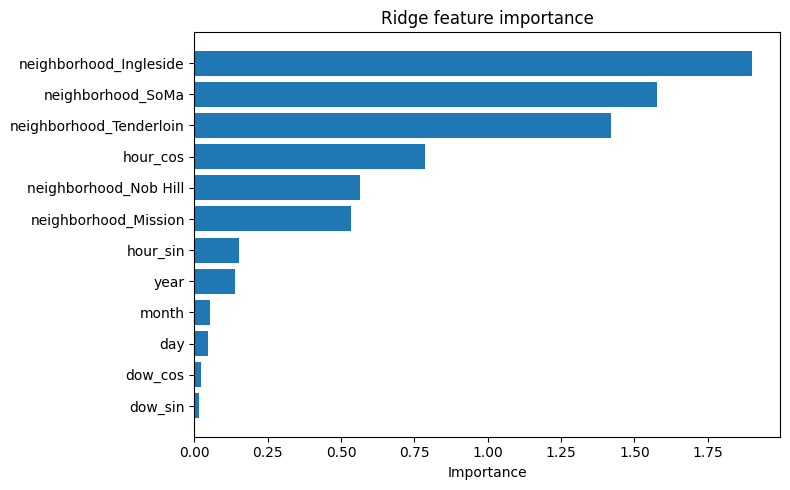

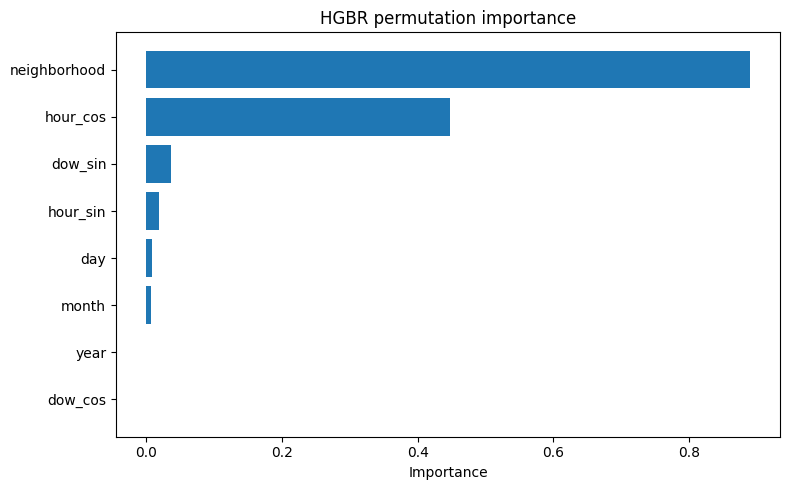

In [18]:
# Ridge
ridge_imp = linear_feature_importance(ridge)
plot_feature_importance(ridge_imp, "importance", "Ridge feature importance")

# HGBR
hgbr_imp = hgbr_permutation_importance(hgbr, X_test, y_test)
plot_feature_importance(hgbr_imp, "importance_mean", "HGBR permutation importance")


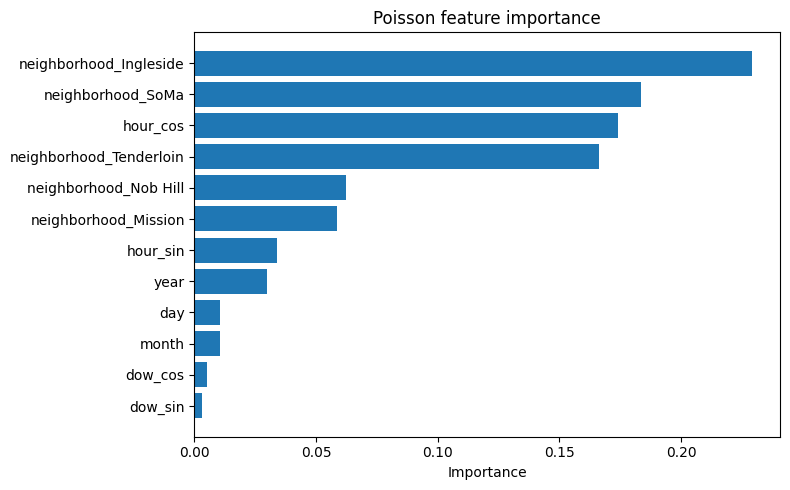

In [19]:
# Ridge
pois_imp = linear_feature_importance(pois)
plot_feature_importance(pois_imp, "importance", "Poisson feature importance")

# Use Weather Data

In [10]:
# Load parquet file into dataframe
# Check https://github.com/awslabs/open-data-docs/tree/main/docs/noaa/noaa-ghcn
# for data spec
sf_weather_df = pd.read_parquet(DATA_PATH / 'weather-data-SF-Nyc-Seattle-2015-2020.parquet')
sf_weather_df.head(5)

,station,date,field,value
0,USW00024233,20150101,TMAX,56
1,USW00024233,20150101,TMIN,-32
2,USW00024233,20150101,PRCP,0
3,USW00024233,20150101,SNWD,0
4,USW00024233,20150101,AWND,12


In [11]:
sf_weather_df['station'].unique()

array(['USW00024233', 'USW00014732', 'USW00023234'], dtype=object)

Check the following TXT document and search for the station.
* http://noaa-ghcn-pds.s3.amazonaws.com/ghcnd-stations.txt

We discovered SF International Airport is `USW00023234`.

In [12]:
len(sf_weather_df)

40393

In [13]:
sf_weather_df = sf_weather_df[sf_weather_df['station'] == 'USW00023234']

In [14]:
sf_weather_df['station'].unique()

array(['USW00023234'], dtype=object)

In [15]:
len(sf_weather_df)

12641

In [16]:
sf_weather_df['field'].unique()

array(['TMAX', 'TMIN', 'PRCP', 'AWND', 'TAVG', 'WSF2', 'SNWD'],
      dtype=object)

* PRCP = Precipitation (tenths of mm)
* SNOW = Snowfall (mm)
* SNWD = Snow depth (mm)
* TMAX = Maximum temperature (tenths of degrees C)
* TMIN = Minimum temperature (tenths of degrees C)
* AWND = Average daily wind speed (tenths of meters per second)
* TAVG = Average temperature (tenths of degrees C) [Note that TAVG from source ’S’ corresponds to an average for the period ending at 2400 UTC rather than local midnight]
* WSF2 = Fastest 2-minute wind speed (tenths of meters per second)

In [17]:
sf_weather_df.describe()

,date,value
count,1.264100e+04,12641.000000
mean,2.017383e+07,95.478997
std,1.571006e+04,72.187428
min,2.015010e+07,0.000000
25%,2.016061e+07,32.000000
50%,2.017112e+07,100.000000
75%,2.019022e+07,144.000000
max,2.020060e+07,792.000000


## Pivot Weather Data From Long to Wide

We need to "pivot" this data apparently.

In [18]:
sf_weather_df.columns

Index(['station', 'date', 'field', 'value'], dtype='object')

In [19]:
sf_weather_df.head(2)

,station,date,field,value
14,USW00023234,20150101,TMAX,128
15,USW00023234,20150101,TMIN,44


In [20]:
# Remove the station, as redundant column value
sf_station_df = sf_weather_df.drop('station', axis=1)

# Render the date column
sf_station_df['date'] = pd.to_datetime(sf_station_df['date'], format="%Y%m%d")

# Create pivot table, date as index, field as columns, values as value
sf_station_pivot = sf_station_df.pivot_table(
                        index='date'
                        ,columns="field"
                        ,values="value"
                        ,aggfunc="mean" # In case we have dupe entries
                        ).sort_index()
sf_station_pivot.columns.name = None
sf_station_pivot.head(10)

,AWND,PRCP,SNWD,TAVG,TMAX,TMIN,WSF2
date,,,,,,,
2015-01-01,38.0,0.0,NaN,97.0,128.0,44.0,89.0
2015-01-02,7.0,0.0,NaN,77.0,111.0,33.0,31.0
2015-01-03,7.0,0.0,NaN,77.0,122.0,33.0,31.0
2015-01-04,9.0,0.0,NaN,86.0,128.0,50.0,63.0
2015-01-05,11.0,0.0,NaN,98.0,150.0,61.0,31.0
2015-01-06,9.0,0.0,NaN,108.0,156.0,67.0,36.0
2015-01-07,9.0,0.0,NaN,116.0,156.0,72.0,31.0
2015-01-08,4.0,0.0,NaN,120.0,156.0,94.0,31.0
2015-01-09,16.0,0.0,NaN,125.0,172.0,106.0,58.0


In [21]:
sf_station_pivot.describe()

,AWND,PRCP,SNWD,TAVG,TMAX,TMIN,WSF2
count,1980.000000,1981.000000,796.0,1982.000000,1961.000000,1961.000000,1980.000000
mean,45.742424,12.622918,0.0,146.913724,194.501275,110.468129,102.093939
std,20.304536,48.908301,0.0,31.087168,45.072664,30.073908,30.926885
min,4.000000,0.000000,0.0,54.000000,89.000000,11.000000,22.000000
25%,31.000000,0.000000,0.0,126.000000,161.000000,94.000000,81.000000
50%,45.000000,0.000000,0.0,147.000000,194.000000,111.000000,103.000000
75%,59.000000,0.000000,0.0,167.000000,222.000000,128.000000,116.000000
max,113.000000,792.000000,0.0,282.000000,400.000000,222.000000,233.000000


In [23]:
sf_station_pivot.head(1)

,AWND,PRCP,SNWD,TAVG,TMAX,TMIN,WSF2
date,,,,,,,
2015-01-01,38.0,0.0,NaN,97.0,128.0,44.0,89.0


In [224]:
feat_df.head(1)

,neighborhood,interval_start,count,year,month,day,dow,hour,dow_sin,dow_cos,hour_sin,hour_cos
0,Mission,2016-01-01,10,2016,1,1,4,0,-0.433884,-0.900969,0.0,1.0


In [225]:
feat_df.head(30)

,neighborhood,interval_start,count,year,month,day,dow,hour,dow_sin,dow_cos,hour_sin,hour_cos
0,Mission,2016-01-01 00:00:00,10,2016,1,1,4,0,-0.433884,-0.900969,0.000000e+00,1.000000e+00
1,Ingleside,2016-01-01 00:00:00,3,2016,1,1,4,0,-0.433884,-0.900969,0.000000e+00,1.000000e+00
2,Nob Hill,2016-01-01 00:00:00,6,2016,1,1,4,0,-0.433884,-0.900969,0.000000e+00,1.000000e+00
3,Tenderloin,2016-01-01 00:00:00,15,2016,1,1,4,0,-0.433884,-0.900969,0.000000e+00,1.000000e+00
4,SoMa,2016-01-01 00:00:00,13,2016,1,1,4,0,-0.433884,-0.900969,0.000000e+00,1.000000e+00
5,Nob Hill,2016-01-01 06:00:00,4,2016,1,1,4,6,-0.433884,-0.900969,1.000000e+00,6.123234e-17
6,Tenderloin,2016-01-01 06:00:00,6,2016,1,1,4,6,-0.433884,-0.900969,1.000000e+00,6.123234e-17
7,Ingleside,2016-01-01 06:00:00,0,2016,1,1,4,6,-0.433884,-0.900969,1.000000e+00,6.123234e-17
8,Mission,2016-01-01 06:00:00,2,2016,1,1,4,6,-0.433884,-0.900969,1.000000e+00,6.123234e-17
9,SoMa,2016-01-01 06:00:00,5,2016,1,1,4,6,-0.433884,-0.900969,1.000000e+00,6.123234e-17


## Merge Weather Data with Current Data

In [33]:
# Confirm our columns
sf_station_pivot.loc[foo['interval_start']]

,AWND,PRCP,SNWD,TAVG,TMAX,TMIN,WSF2
date,,,,,,,
2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0
2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0
2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0
2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0
2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0


In [44]:
# Test Dataframe
foo = feat_df.head(5)

foo = foo.merge(sf_station_pivot, left_on='interval_start', right_on='date')
foo

,neighborhood,interval_start,count,year,month,day,dow,hour,dow_sin,dow_cos,hour_sin,hour_cos,AWND,PRCP,SNWD,TAVG,TMAX,TMIN,WSF2
0,Mission,2016-01-01,10,2016,1,1,4,0,-0.433884,-0.900969,0.0,1.0,39.0,0.0,NaN,70.0,94.0,28.0,76.0
1,Ingleside,2016-01-01,3,2016,1,1,4,0,-0.433884,-0.900969,0.0,1.0,39.0,0.0,NaN,70.0,94.0,28.0,76.0
2,Nob Hill,2016-01-01,6,2016,1,1,4,0,-0.433884,-0.900969,0.0,1.0,39.0,0.0,NaN,70.0,94.0,28.0,76.0
3,Tenderloin,2016-01-01,15,2016,1,1,4,0,-0.433884,-0.900969,0.0,1.0,39.0,0.0,NaN,70.0,94.0,28.0,76.0
4,SoMa,2016-01-01,13,2016,1,1,4,0,-0.433884,-0.900969,0.0,1.0,39.0,0.0,NaN,70.0,94.0,28.0,76.0


In [237]:
# Create a copy of feat_df
feat_df_date = feat_df.copy()

# Set a column *just* with a date. This is an 'object' datatype
feat_df_date['date'] = feat_df_date['interval_start'].dt.date

# Turn the object back into a datetime
feat_df_date['date'] = pd.to_datetime(feat_df_date['date'])

# Merge the dataframes on date coumns
feat_df_date = feat_df_date.merge(sf_station_pivot, left_on='date', right_on='date')

# We cannot join `interval_start` directly with `date` since it will only match with 00:00:00 and not subsequent hours.
feat_df_date.head(10)

,neighborhood,interval_start,count,year,month,day,dow,hour,dow_sin,dow_cos,hour_sin,hour_cos,date,AWND,PRCP,SNWD,TAVG,TMAX,TMIN,WSF2
0,Mission,2016-01-01 00:00:00,10,2016,1,1,4,0,-0.433884,-0.900969,0.0,1.000000e+00,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0
1,Ingleside,2016-01-01 00:00:00,3,2016,1,1,4,0,-0.433884,-0.900969,0.0,1.000000e+00,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0
2,Nob Hill,2016-01-01 00:00:00,6,2016,1,1,4,0,-0.433884,-0.900969,0.0,1.000000e+00,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0
3,Tenderloin,2016-01-01 00:00:00,15,2016,1,1,4,0,-0.433884,-0.900969,0.0,1.000000e+00,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0
4,SoMa,2016-01-01 00:00:00,13,2016,1,1,4,0,-0.433884,-0.900969,0.0,1.000000e+00,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0
5,Nob Hill,2016-01-01 06:00:00,4,2016,1,1,4,6,-0.433884,-0.900969,1.0,6.123234e-17,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0
6,Tenderloin,2016-01-01 06:00:00,6,2016,1,1,4,6,-0.433884,-0.900969,1.0,6.123234e-17,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0
7,Ingleside,2016-01-01 06:00:00,0,2016,1,1,4,6,-0.433884,-0.900969,1.0,6.123234e-17,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0
8,Mission,2016-01-01 06:00:00,2,2016,1,1,4,6,-0.433884,-0.900969,1.0,6.123234e-17,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0
9,SoMa,2016-01-01 06:00:00,5,2016,1,1,4,6,-0.433884,-0.900969,1.0,6.123234e-17,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0


In [238]:
feat_df_date.dtypes

neighborhood            category
interval_start    datetime64[ns]
count                      int64
year                       int32
month                       int8
day                         int8
dow                         int8
hour                        int8
dow_sin                  float64
dow_cos                  float64
hour_sin                 float64
hour_cos                 float64
date              datetime64[ns]
AWND                     float64
PRCP                     float64
SNWD                     float64
TAVG                     float64
TMAX                     float64
TMIN                     float64
WSF2                     float64
dtype: object

In [239]:
# Save the merged dataframe
%store feat_df_date

Stored 'feat_df_date' (DataFrame)


In [104]:
%store -r feat_df

# Add Holiday Data

In [241]:
import holidays
from datetime import date
import holidays

us_holidays = holidays.US()  # this is a dict-like object
# the below is the same, but takes a string:
us_holidays = holidays.country_holidays('US')  # this is a dict-like object


date(2015, 1, 1) in us_holidays  # True
date(2015, 1, 2) in us_holidays  # False
us_holidays.get('2014-01-01')  # "New Year's Day"
holiday_dates = set(us_holidays.keys())

# Create new dataframe with holiday col
feat_df_date_holiday = feat_df_date.copy()
feat_df_date_holiday["is_holiday"] = feat_df_date["interval_start"].dt.date.isin(holiday_dates)
feat_df_date_holiday.head(5)

,neighborhood,interval_start,count,year,month,day,dow,hour,dow_sin,dow_cos,...,hour_cos,date,AWND,PRCP,SNWD,TAVG,TMAX,TMIN,WSF2,is_holiday
0,Mission,2016-01-01,10,2016,1,1,4,0,-0.433884,-0.900969,...,1.0,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0,False
1,Ingleside,2016-01-01,3,2016,1,1,4,0,-0.433884,-0.900969,...,1.0,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0,False
2,Nob Hill,2016-01-01,6,2016,1,1,4,0,-0.433884,-0.900969,...,1.0,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0,False
3,Tenderloin,2016-01-01,15,2016,1,1,4,0,-0.433884,-0.900969,...,1.0,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0,False
4,SoMa,2016-01-01,13,2016,1,1,4,0,-0.433884,-0.900969,...,1.0,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0,False


In [97]:
us_holidays.get('2016-01-02')

In [98]:
import holidays

us_holidays = holidays.US()

holiday_dates = set(us_holidays.keys())  # <-- THIS is the fix

#df["is_holiday"] = df["interval_start"].dt.date.isin(holiday_dates)
holiday_dates

set()

In [81]:
# feat_df['is_holiday'] = 
# print(int(isinstance(us_holidays.get(date_string), str)))

1


In [244]:
import holidays

# interval_start is datetime64[ns]
years = feat_df["interval_start"].dt.year.unique().tolist()

us_holidays = holidays.US(years=years)   # <-- forces generation for those years
holiday_dates = set(us_holidays)         # iterating yields the holiday dates

feat_df_date_holiday = feat_df_date.copy()
feat_df_date_holiday["is_holiday"] = feat_df_date["interval_start"].dt.date.isin(holiday_dates)
feat_df_date_holiday.head(50)

,neighborhood,interval_start,count,year,month,day,dow,hour,dow_sin,dow_cos,...,hour_cos,date,AWND,PRCP,SNWD,TAVG,TMAX,TMIN,WSF2,is_holiday
0,Mission,2016-01-01 00:00:00,10,2016,1,1,4,0,-0.433884,-0.900969,...,1.000000e+00,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0,True
1,Ingleside,2016-01-01 00:00:00,3,2016,1,1,4,0,-0.433884,-0.900969,...,1.000000e+00,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0,True
2,Nob Hill,2016-01-01 00:00:00,6,2016,1,1,4,0,-0.433884,-0.900969,...,1.000000e+00,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0,True
3,Tenderloin,2016-01-01 00:00:00,15,2016,1,1,4,0,-0.433884,-0.900969,...,1.000000e+00,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0,True
4,SoMa,2016-01-01 00:00:00,13,2016,1,1,4,0,-0.433884,-0.900969,...,1.000000e+00,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0,True
5,Nob Hill,2016-01-01 06:00:00,4,2016,1,1,4,6,-0.433884,-0.900969,...,6.123234e-17,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0,True
6,Tenderloin,2016-01-01 06:00:00,6,2016,1,1,4,6,-0.433884,-0.900969,...,6.123234e-17,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0,True
7,Ingleside,2016-01-01 06:00:00,0,2016,1,1,4,6,-0.433884,-0.900969,...,6.123234e-17,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0,True
8,Mission,2016-01-01 06:00:00,2,2016,1,1,4,6,-0.433884,-0.900969,...,6.123234e-17,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0,True
9,SoMa,2016-01-01 06:00:00,5,2016,1,1,4,6,-0.433884,-0.900969,...,6.123234e-17,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0,True


In [245]:
# Sanity check
len(holiday_dates), sorted(list(holiday_dates))[:5]
feat_df_date_holiday["is_holiday"].value_counts(dropna=False)

is_holiday
False    28340
True       880
Name: count, dtype: int64

In [246]:
# Add in California Hholidays
ca_holidays = holidays.US(state="CA", years=years)
holiday_dates = set(ca_holidays)

feat_df_date_holiday["is_ca_holiday"] = feat_df_date_holiday["interval_start"].dt.date.isin(holiday_dates)

In [247]:
# Sanity check after we add CA holidays
len(holiday_dates), sorted(list(holiday_dates))[:5]
feat_df_date_holiday["is_ca_holiday"].value_counts(dropna=False)

is_ca_holiday
False    28180
True      1040
Name: count, dtype: int64

In [248]:
%store feat_df_date_holiday

Stored 'feat_df_date_holiday' (DataFrame)


In [249]:
feat_df_date_holiday.head(1)

,neighborhood,interval_start,count,year,month,day,dow,hour,dow_sin,dow_cos,...,date,AWND,PRCP,SNWD,TAVG,TMAX,TMIN,WSF2,is_holiday,is_ca_holiday
0,Mission,2016-01-01,10,2016,1,1,4,0,-0.433884,-0.900969,...,2016-01-01,39.0,0.0,NaN,70.0,94.0,28.0,76.0,True,True


Now we have a conundrum. We can add street cleaning schedule data, but that data has "cnn" and not a neighborhood.
* Map a neighborhood to CNN
* Aggregate or process the schedule so that we get numerical data per neighborhood.
* Assign / associate the count street cleanings to `dow`. 

In [116]:
import pathlib
# set root path
ROOT = pathlib.Path().resolve().parents[0]

# Create path object for wyscout
sf_data_path = ROOT / "Github"/ "predicting_urban_events_with_scikit_learn"/ "data"  


In [117]:
sf_data_path

WindowsPath('C:/Users/lover/Documents/Github/predicting_urban_events_with_scikit_learn/data')

In [118]:
streets_path = sf_data_path / "Streets_–_Active_and_Retired_20260118.csv"

In [119]:
streets_df = pd.read_csv(streets_path)
streets_df.head(1)

,cnn,lf_fadd,lf_toadd,rt_fadd,rt_toadd,street,st_type,f_st,t_st,f_node_cnn,...,oneway,street_gc,streetname,streetname_gc,zip_code,analysis_neighborhood,supervisor_district,line,data_as_of,data_loaded_at
0,944000,1101.0,1199.0,1100.0,1198.0,19TH,ST,PENNSYLVANIA AVE,MISSISSIPPI ST,23649000.0,...,B,19TH,19TH ST,19TH ST,94107.0,Potrero Hill,10.0,"LINESTRING (-122.393488387 37.761476161, -122....",2026/01/17 03:57:00 AM,2026/01/17 10:14:19 AM


In [121]:
print(streets_df.head(1)['line'])

0    LINESTRING (-122.393488387 37.761476161, -122....
Name: line, dtype: object


In [122]:
sweeping_schedule_path = sf_data_path / "Street_Sweeping_Schedule_20260118.csv"

In [124]:
sweeping_schedule_df = pd.read_csv(sweeping_schedule_path)
sweeping_schedule_df.head(1)

,CNN,Corridor,Limits,CNNRightLeft,BlockSide,FullName,WeekDay,FromHour,ToHour,Week1,Week2,Week3,Week4,Week5,Holidays,BlockSweepID,Line
0,8753101,Market St,Larkin St - Polk St,L,SouthEast,Tuesday,Tues,5,6,1,1,1,1,1,0,1640782,"LINESTRING (-122.416291701103 37.777493843394,..."


In [125]:
import duckdb

In [168]:
duckdb.sql("""
SELECT 
    -- schedule.cnn
    DISTINCT (streets.analysis_neighborhood
    ,schedule.weekday) AS neighborhood_and_day
    ,COUNT(analysis_neighborhood) AS hood_count
FROM streets_df AS streets
JOIN sweeping_schedule_df AS schedule
    ON schedule.CNN = streets.cnn
--WHERE streets.active = True
GROUP BY 
    streets.analysis_neighborhood
    ,schedule.cnn
    ,schedule.weekday
HAVING hood_count > 0
ORDER BY 
    hood_count DESC
    ,neighborhood_and_day ASC

""")

┌─────────────────────────────┬────────────┐
│    neighborhood_and_day     │ hood_count │
│  struct(varchar, varchar)   │   int64    │
├─────────────────────────────┼────────────┤
│ (Bernal Heights, Fri)       │          4 │
│ (Bernal Heights, Mon)       │          4 │
│ (Bernal Heights, Thu)       │          4 │
│ (Bernal Heights, Tues)      │          4 │
│ (Bernal Heights, Wed)       │          4 │
│ (Chinatown, Tues)           │          4 │
│ (Japantown, Fri)            │          4 │
│ (Lakeshore, Tues)           │          4 │
│ (Lakeshore, Wed)            │          4 │
│ (Lone Mountain/USF, Mon)    │          4 │
│            ·                │          · │
│            ·                │          · │
│            ·                │          · │
│ (West of Twin Peaks, Tues)  │          1 │
│ (West of Twin Peaks, Wed)   │          1 │
│ (Western Addition, Fri)     │          1 │
│ (Western Addition, Holiday) │          1 │
│ (Western Addition, Mon)     │          1 │
│ (Western

We can render the SQL output into a dataframe...
* We can then add columns based on the neighborhood and day
* Separately, we then populate our feature dataframe, by looking up from the SQL result by the neighborhood + day of week
* Get the count of cleanings that day of week
* Add the count of cleanings in that neighborhood and dow to thefeature dataframe

We must be cautious that the Day of Week we translate from our SQL maps correctly into the feature dataframe.

In [142]:
feat_df_holidays.head(30).query('dow == 6')

,neighborhood,interval_start,count,year,month,day,dow,hour,dow_sin,dow_cos,...,hour_cos,AWND,PRCP,SNWD,TAVG,TMAX,TMIN,WSF2,is_holiday,is_ca_holiday
10,SoMa,2016-01-03,3,2016,1,3,6,0,-0.781831,0.62349,...,1.0,9.0,10.0,NaN,88.0,117.0,67.0,40.0,False,False
11,Mission,2016-01-03,3,2016,1,3,6,0,-0.781831,0.62349,...,1.0,9.0,10.0,NaN,88.0,117.0,67.0,40.0,False,False
12,Tenderloin,2016-01-03,9,2016,1,3,6,0,-0.781831,0.62349,...,1.0,9.0,10.0,NaN,88.0,117.0,67.0,40.0,False,False
13,Ingleside,2016-01-03,4,2016,1,3,6,0,-0.781831,0.62349,...,1.0,9.0,10.0,NaN,88.0,117.0,67.0,40.0,False,False
14,Nob Hill,2016-01-03,0,2016,1,3,6,0,-0.781831,0.62349,...,1.0,9.0,10.0,NaN,88.0,117.0,67.0,40.0,False,False


So, Day 0, in our feature dataframe is "Monday." Here is our lookup.
* 0 = Monday
* 1 = Tuesday
* 2 = Wednesday
* 3 = Thursday
* 4 = Friday
* 5 = Saturday
* 6 = Sunday

# Use Street Sweeping Data

In [162]:
duckdb.sql("""
SELECT 
    streets.analysis_neighborhood
    ,schedule.weekday
--    ,COUNT (DISTINCT schedule.cnn)
    ,COUNT schedule.cnn
    --DISTINCT (streets.analysis_neighborhood
    --,schedule.weekday) AS neighborhood_and_day
FROM sweeping_schedule_df AS schedule

JOIN streets_df AS streets
    ON schedule.CNN = streets.cnn
WHERE 
    streets.analysis_neighborhood IS NOT NULL
    -- AND streets.analysis_neighborhood = 'Twin Peaks'
GROUP BY 
    streets.analysis_neighborhood
    ,schedule.weekday
ORDER BY 
    COUNT(schedule.cnn) DESC
    
""")

┌────────────────────────────────┬─────────┬──────────────────────────────┐
│     analysis_neighborhood      │ WeekDay │ count(DISTINCT schedule.cnn) │
│            varchar             │ varchar │            int64             │
├────────────────────────────────┼─────────┼──────────────────────────────┤
│ Sunset/Parkside                │ Tues    │                          620 │
│ Sunset/Parkside                │ Thu     │                          579 │
│ Sunset/Parkside                │ Mon     │                          575 │
│ Sunset/Parkside                │ Fri     │                          536 │
│ Mission                        │ Thu     │                          535 │
│ Mission                        │ Tues    │                          552 │
│ Mission                        │ Fri     │                          486 │
│ West of Twin Peaks             │ Wed     │                          460 │
│ Mission                        │ Mon     │                          465 │
│ Financial 

In [164]:
duckdb.sql("""
SELECT 
    streets.analysis_neighborhood
    ,schedule.weekday
--    ,COUNT (DISTINCT schedule.cnn)
    ,COUNT (schedule.cnn)
    --DISTINCT (streets.analysis_neighborhood
    --,schedule.weekday) AS neighborhood_and_day
FROM sweeping_schedule_df AS schedule

JOIN streets_df AS streets
    ON schedule.CNN = streets.cnn
WHERE 
    streets.analysis_neighborhood IS NOT NULL
    -- AND streets.analysis_neighborhood = 'Twin Peaks'
GROUP BY 
    streets.analysis_neighborhood
    ,schedule.weekday
ORDER BY 
    COUNT(schedule.cnn) DESC
    
""")

┌────────────────────────────────┬─────────┬─────────────────────┐
│     analysis_neighborhood      │ WeekDay │ count(schedule.cnn) │
│            varchar             │ varchar │        int64        │
├────────────────────────────────┼─────────┼─────────────────────┤
│ Sunset/Parkside                │ Tues    │                 760 │
│ Sunset/Parkside                │ Thu     │                 700 │
│ Sunset/Parkside                │ Mon     │                 678 │
│ Sunset/Parkside                │ Fri     │                 665 │
│ Mission                        │ Thu     │                 626 │
│ Mission                        │ Tues    │                 612 │
│ Mission                        │ Fri     │                 550 │
│ West of Twin Peaks             │ Wed     │                 547 │
│ Mission                        │ Mon     │                 526 │
│ Financial District/South Beach │ Mon     │                 505 │
│        ·                       │  ·      │                  

In [169]:
duckdb.query("""
SELECT
    streets.analysis_neighborhood,
    schedule.weekday,
    COUNT(DISTINCT schedule.cnn) AS scheduled_street_segments
FROM sweeping_schedule_df AS schedule
JOIN streets_df AS streets
  ON schedule.cnn = streets.cnn
WHERE streets.analysis_neighborhood IS NOT NULL
AND streets.active = True
GROUP BY 1, 2
ORDER BY scheduled_street_segments DESC;
""")

┌────────────────────────────┬─────────┬───────────────────────────┐
│   analysis_neighborhood    │ WeekDay │ scheduled_street_segments │
│          varchar           │ varchar │           int64           │
├────────────────────────────┼─────────┼───────────────────────────┤
│ Sunset/Parkside            │ Tues    │                       620 │
│ Sunset/Parkside            │ Thu     │                       579 │
│ Sunset/Parkside            │ Mon     │                       575 │
│ Mission                    │ Tues    │                       552 │
│ Sunset/Parkside            │ Fri     │                       536 │
│ Mission                    │ Thu     │                       535 │
│ Mission                    │ Fri     │                       486 │
│ Mission                    │ Mon     │                       465 │
│ West of Twin Peaks         │ Wed     │                       458 │
│ Bayview Hunters Point      │ Thu     │                       435 │
│        ·                   │  · 

In [170]:
duckdb.query("""SELECT cnn, COUNT(*) AS n
FROM streets_df
GROUP BY 1
HAVING COUNT(*) > 1
ORDER BY n DESC
LIMIT 20;
""")

┌───────┬───────┐
│  cnn  │   n   │
│ int64 │ int64 │
├───────┴───────┤
│    0 rows     │
└───────────────┘

In [172]:
duckdb.query("""SELECT cnn, weekday, COUNT(*) AS n
FROM sweeping_schedule_df
GROUP BY 1, 2
HAVING COUNT(*) > 1
ORDER BY n DESC
LIMIT 20;
""")

┌──────────┬─────────┬───────┐
│   CNN    │ WeekDay │   n   │
│  int64   │ varchar │ int64 │
├──────────┼─────────┼───────┤
│  9130000 │ Wed     │     4 │
│  9144000 │ Thu     │     4 │
│  9145000 │ Fri     │     4 │
│  9133000 │ Thu     │     4 │
│  9140000 │ Wed     │     4 │
│  9134000 │ Thu     │     4 │
│  9145000 │ Thu     │     4 │
│  9138000 │ Tues    │     4 │
│  9138000 │ Mon     │     4 │
│  9139000 │ Thu     │     4 │
│  9130000 │ Fri     │     4 │
│  9138000 │ Fri     │     4 │
│  9129000 │ Wed     │     4 │
│  2566000 │ Fri     │     4 │
│  9130000 │ Mon     │     4 │
│ 12611000 │ Tues    │     4 │
│  9145000 │ Tues    │     4 │
│  9145000 │ Mon     │     4 │
│  9146000 │ Thu     │     4 │
│  8562000 │ Mon     │     4 │
├──────────┴─────────┴───────┤
│ 20 rows          3 columns │
└────────────────────────────┘

In [173]:
streets_df.columns

Index(['cnn', 'lf_fadd', 'lf_toadd', 'rt_fadd', 'rt_toadd', 'street',
       'st_type', 'f_st', 't_st', 'f_node_cnn', 't_node_cnn', 'accepted',
       'active', 'classcode', 'date_added', 'date_altered', 'date_dropped',
       'gds_chg_id_add', 'gds_chg_id_altered', 'gds_chg_id_dropped',
       'jurisdiction', 'layer', 'nhood', 'oneway', 'street_gc', 'streetname',
       'streetname_gc', 'zip_code', 'analysis_neighborhood',
       'supervisor_district', 'line', 'data_as_of', 'data_loaded_at'],
      dtype='object')

In [174]:
duckdb.query("""SELECT *
FROM sweeping_schedule_df
WHERE cnn = 9130000 AND weekday = 'Wed'
LIMIT 50;
""")


┌─────────┬────────────┬────────────────────────────┬──────────────┬───────────┬───────────────────┬─────────┬──────────┬────────┬───────┬───────┬───────┬───────┬───────┬──────────┬──────────────┬───────────────────────────────────────────────────────────────────────────────────┐
│   CNN   │  Corridor  │           Limits           │ CNNRightLeft │ BlockSide │     FullName      │ WeekDay │ FromHour │ ToHour │ Week1 │ Week2 │ Week3 │ Week4 │ Week5 │ Holidays │ BlockSweepID │                                       Line                                        │
│  int64  │  varchar   │          varchar           │   varchar    │  varchar  │      varchar      │ varchar │  int64   │ int64  │ int64 │ int64 │ int64 │ int64 │ int64 │  int64   │    int64     │                                      varchar                                      │
├─────────┼────────────┼────────────────────────────┼──────────────┼───────────┼───────────────────┼─────────┼──────────┼────────┼───────┼───────┼───────┼───

In [175]:
duckdb.query("""WITH date_spine AS (
  SELECT
    d::DATE AS dt,
    strftime(d::DATE, '%a') AS weekday, -- Mon/Tue/Wed...
    1 + ((extract(day from d::DATE) - 1) / 7) AS week_of_month
  FROM generate_series(date '2016-01-01', date '2019-12-31', interval 1 day) AS t(d)
)
SELECT * FROM date_spine LIMIT 10;
""")

┌────────────┬─────────┬────────────────────┐
│     dt     │ weekday │   week_of_month    │
│    date    │ varchar │       double       │
├────────────┼─────────┼────────────────────┤
│ 2016-01-01 │ Fri     │                1.0 │
│ 2016-01-02 │ Sat     │ 1.1428571428571428 │
│ 2016-01-03 │ Sun     │ 1.2857142857142856 │
│ 2016-01-04 │ Mon     │ 1.4285714285714286 │
│ 2016-01-05 │ Tue     │ 1.5714285714285714 │
│ 2016-01-06 │ Wed     │ 1.7142857142857144 │
│ 2016-01-07 │ Thu     │ 1.8571428571428572 │
│ 2016-01-08 │ Fri     │                2.0 │
│ 2016-01-09 │ Sat     │  2.142857142857143 │
│ 2016-01-10 │ Sun     │ 2.2857142857142856 │
├────────────┴─────────┴────────────────────┤
│ 10 rows                         3 columns │
└───────────────────────────────────────────┘

In [253]:
# Join schedule to our "date spine" using weekday + week of the month.
# "How many schedule street-side sweeps exist on that date in that neighborhood?"

duckdb.query("""
WITH date_spine AS (
  SELECT
    d::DATE AS dt,
    strftime(d::DATE, '%a') AS weekday,
    1 + ((extract(day from d::DATE) - 1) / 7) AS week_of_month
  FROM generate_series(date '2016-01-01', date '2019-12-31', interval 1 day) AS t(d)
),
sched AS (
  SELECT
    schedule.cnn,
    schedule.weekday,
    schedule.fromhour,
    schedule.tohour,
    schedule.week1, schedule.week2, schedule.week3, schedule.week4, schedule.week5
  FROM sweeping_schedule_df AS schedule
),
joined AS (
  SELECT
    streets.analysis_neighborhood,
    ds.dt,
    ds.weekday,
    ds.week_of_month,
    sched.cnn
  FROM date_spine ds
  JOIN sched
    ON sched.weekday = ds.weekday
   AND (
        (ds.week_of_month = 1 AND sched.week1 = 1) OR
        (ds.week_of_month = 2 AND sched.week2 = 1) OR
        (ds.week_of_month = 3 AND sched.week3 = 1) OR
        (ds.week_of_month = 4 AND sched.week4 = 1) OR
        (ds.week_of_month = 5 AND sched.week5 = 1)
      )
  JOIN streets_df streets
    ON streets.cnn = sched.cnn
  WHERE streets.analysis_neighborhood IS NOT NULL
    AND streets.active = 'True'
)
SELECT
  analysis_neighborhood,
  dt,
  COUNT(*) AS scheduled_sweeps
FROM joined
GROUP BY 1, 2
ORDER BY scheduled_sweeps DESC;


""")

┌───────────────────────┬────────────┬──────────────────┐
│ analysis_neighborhood │     dt     │ scheduled_sweeps │
│        varchar        │    date    │      int64       │
├───────────────────────┼────────────┼──────────────────┤
│ Mission               │ 2017-06-08 │              578 │
│ Mission               │ 2019-08-22 │              578 │
│ Mission               │ 2018-11-22 │              578 │
│ Mission               │ 2018-03-08 │              578 │
│ Mission               │ 2016-09-22 │              578 │
│ Mission               │ 2016-12-08 │              578 │
│ Mission               │ 2019-08-08 │              578 │
│ Mission               │ 2018-02-08 │              578 │
│ Mission               │ 2017-06-22 │              578 │
│ Mission               │ 2016-09-08 │              578 │
│    ·                  │     ·      │                · │
│    ·                  │     ·      │                · │
│    ·                  │     ·      │                · │
│ Twin Peaks  

In [255]:
# Join schedule to our "date spine" using weekday + week of the month.
# "How many schedule street-side sweeps exist on that date in that neighborhood?"

duckdb.query("""
WITH date_spine AS (
  SELECT
    d::DATE AS dt,
    strftime(d::DATE, '%a') AS weekday,
    1 + ((extract(day from d::DATE) - 1) / 7) AS week_of_month
  FROM generate_series(date '2016-01-01', date '2019-12-31', interval 1 day) AS t(d)
),
sched AS (
  SELECT
    schedule.cnn,
    schedule.weekday,
    schedule.fromhour,
    schedule.tohour,
    schedule.week1, schedule.week2, schedule.week3, schedule.week4, schedule.week5
  FROM sweeping_schedule_df AS schedule
),
joined AS (
  SELECT
    streets.analysis_neighborhood,
    ds.dt,
    ds.weekday,
    ds.week_of_month,
    sched.cnn,
    sched.fromhour,
    sched.tohour
  FROM date_spine ds
  JOIN sched
    ON sched.weekday = ds.weekday
   AND (
        (ds.week_of_month = 1 AND sched.week1 = 1) OR
        (ds.week_of_month = 2 AND sched.week2 = 1) OR
        (ds.week_of_month = 3 AND sched.week3 = 1) OR
        (ds.week_of_month = 4 AND sched.week4 = 1) OR
        (ds.week_of_month = 5 AND sched.week5 = 1)
      )
  JOIN streets_df streets
    ON streets.cnn = sched.cnn
  WHERE streets.analysis_neighborhood IS NOT NULL
    AND streets.active = 'True'
)
SELECT
  analysis_neighborhood,
  dt,
  fromhour,
  tohour,
  COUNT(*) AS scheduled_sweeps
FROM joined
GROUP BY 1, 2, 3, 4
ORDER BY scheduled_sweeps DESC;


""")

┌────────────────────────────────┬────────────┬──────────┬────────┬──────────────────┐
│     analysis_neighborhood      │     dt     │ FromHour │ ToHour │ scheduled_sweeps │
│            varchar             │    date    │  int64   │ int64  │      int64       │
├────────────────────────────────┼────────────┼──────────┼────────┼──────────────────┤
│ Financial District/South Beach │ 2017-05-15 │        2 │      6 │              288 │
│ Financial District/South Beach │ 2016-02-22 │        2 │      6 │              288 │
│ Financial District/South Beach │ 2018-01-15 │        2 │      6 │              288 │
│ Financial District/South Beach │ 2016-02-29 │        2 │      6 │              288 │
│ Financial District/South Beach │ 2016-08-15 │        2 │      6 │              288 │
│ Financial District/South Beach │ 2017-05-01 │        2 │      6 │              288 │
│ Financial District/South Beach │ 2018-01-08 │        2 │      6 │              288 │
│ Financial District/South Beach │ 2016-08-

In [257]:
# Join schedule to our "date spine" using weekday + week of the month.
# "How many schedule street-side sweeps exist on that date in that neighborhood?"

full_scheduling_df = duckdb.query("""
WITH date_spine AS (
  SELECT
    d::DATE AS dt,
    strftime(d::DATE, '%a') AS weekday,
    1 + ((extract(day from d::DATE) - 1) / 7) AS week_of_month
  FROM generate_series(date '2016-01-01', date '2019-12-31', interval 1 day) AS t(d)
),
sched AS (
  SELECT
    schedule.cnn,
    schedule.weekday,
    schedule.fromhour,
    schedule.tohour,
    schedule.week1, schedule.week2, schedule.week3, schedule.week4, schedule.week5
  FROM sweeping_schedule_df AS schedule
),
joined AS (
  SELECT
    streets.analysis_neighborhood,
    ds.dt,
    ds.weekday,
    ds.week_of_month,
    sched.cnn,
    sched.fromhour,
    sched.tohour
  FROM date_spine ds
  JOIN sched
    ON sched.weekday = ds.weekday
   AND (
        (ds.week_of_month = 1 AND sched.week1 = 1) OR
        (ds.week_of_month = 2 AND sched.week2 = 1) OR
        (ds.week_of_month = 3 AND sched.week3 = 1) OR
        (ds.week_of_month = 4 AND sched.week4 = 1) OR
        (ds.week_of_month = 5 AND sched.week5 = 1)
      )
  JOIN streets_df streets
    ON streets.cnn = sched.cnn
  WHERE streets.analysis_neighborhood IS NOT NULL
    AND streets.active = 'True'
)
SELECT
  analysis_neighborhood,
  dt,
  fromhour,
  tohour,
  COUNT(*) AS scheduled_sweeps
FROM joined
GROUP BY 1, 2, 3, 4
ORDER BY scheduled_sweeps DESC;


""").df()

In [256]:
feat_df_date_holiday[feat_df_date_holiday['date'] == "2016-01-02"]

,neighborhood,interval_start,count,year,month,day,dow,hour,dow_sin,dow_cos,...,date,AWND,PRCP,SNWD,TAVG,TMAX,TMIN,WSF2,is_holiday,is_ca_holiday
20,Tenderloin,2016-01-02 00:00:00,4,2016,1,2,5,0,-0.974928,-0.222521,...,2016-01-02,27.0,0.0,NaN,77.0,106.0,67.0,67.0,False,False
21,Nob Hill,2016-01-02 00:00:00,3,2016,1,2,5,0,-0.974928,-0.222521,...,2016-01-02,27.0,0.0,NaN,77.0,106.0,67.0,67.0,False,False
22,SoMa,2016-01-02 00:00:00,8,2016,1,2,5,0,-0.974928,-0.222521,...,2016-01-02,27.0,0.0,NaN,77.0,106.0,67.0,67.0,False,False
23,Mission,2016-01-02 00:00:00,4,2016,1,2,5,0,-0.974928,-0.222521,...,2016-01-02,27.0,0.0,NaN,77.0,106.0,67.0,67.0,False,False
24,Ingleside,2016-01-02 00:00:00,2,2016,1,2,5,0,-0.974928,-0.222521,...,2016-01-02,27.0,0.0,NaN,77.0,106.0,67.0,67.0,False,False
25,Ingleside,2016-01-02 06:00:00,1,2016,1,2,5,6,-0.974928,-0.222521,...,2016-01-02,27.0,0.0,NaN,77.0,106.0,67.0,67.0,False,False
26,Tenderloin,2016-01-02 06:00:00,9,2016,1,2,5,6,-0.974928,-0.222521,...,2016-01-02,27.0,0.0,NaN,77.0,106.0,67.0,67.0,False,False
27,Mission,2016-01-02 06:00:00,6,2016,1,2,5,6,-0.974928,-0.222521,...,2016-01-02,27.0,0.0,NaN,77.0,106.0,67.0,67.0,False,False
28,Nob Hill,2016-01-02 06:00:00,2,2016,1,2,5,6,-0.974928,-0.222521,...,2016-01-02,27.0,0.0,NaN,77.0,106.0,67.0,67.0,False,False
29,SoMa,2016-01-02 06:00:00,2,2016,1,2,5,6,-0.974928,-0.222521,...,2016-01-02,27.0,0.0,NaN,77.0,106.0,67.0,67.0,False,False


We have "clean" neighborhood names in our feature dataframe, while they appar a bit wilder in the scheduling SQL output dataframe.

In [258]:
full_scheduling_df['analysis_neighborhood'].unique()

array(['Financial District/South Beach', 'Chinatown', 'Mission',
       'Outer Mission', 'South of Market', 'Bayview Hunters Point',
       'Visitacion Valley', 'Tenderloin', 'Portola', 'Sunset/Parkside',
       'West of Twin Peaks', 'Marina', 'Excelsior', 'Bernal Heights',
       'Outer Richmond', 'Noe Valley', 'Hayes Valley', 'Potrero Hill',
       'Oceanview/Merced/Ingleside', 'North Beach', 'Lakeshore',
       'Inner Sunset', 'Western Addition', 'Castro/Upper Market',
       'Haight Ashbury', 'Inner Richmond', 'Glen Park', 'Mission Bay',
       'Lone Mountain/USF', 'Nob Hill', 'Pacific Heights', 'Twin Peaks',
       'Presidio Heights', 'Seacliff', 'Golden Gate Park', 'Russian Hill',
       'Japantown', 'McLaren Park', 'Treasure Island', 'Lincoln Park',
       'Presidio'], dtype=object)

In [259]:
feat_df_date_holiday['neighborhood'].unique()

['Mission', 'Ingleside', 'Nob Hill', 'Tenderloin', 'SoMa']
Categories (5, object): ['Mission', 'SoMa', 'Tenderloin', 'Nob Hill', 'Ingleside']

This is a PITA. 
* "Mission" in the feature dataframe could be "Outer Mission" or "Mission.
* "Nob Hill" and "Tenderloin" are directly mapped.
* "Ingleside" maps to 'Oceanview/Merced/Ingleside.'
* "SoMa" is "South of Market."

In [266]:
neighborhoods = full_scheduling_df['analysis_neighborhood'].unique()

condlist = [neighborhoods == "Mission",
            neighborhoods == "Outer Mission",
            neighborhoods == "Oceanview/Merced/Ingleside",
            neighborhoods == "South of Market"
           ]
choicelist=["Mission", "Mission", "Ingleside", "SoMa"]
np.select(condlist, choicelist, neighborhoods)

array(['Financial District/South Beach', 'Chinatown', 'Mission',
       'Mission', 'SoMa', 'Bayview Hunters Point', 'Visitacion Valley',
       'Tenderloin', 'Portola', 'Sunset/Parkside', 'West of Twin Peaks',
       'Marina', 'Excelsior', 'Bernal Heights', 'Outer Richmond',
       'Noe Valley', 'Hayes Valley', 'Potrero Hill', 'Ingleside',
       'North Beach', 'Lakeshore', 'Inner Sunset', 'Western Addition',
       'Castro/Upper Market', 'Haight Ashbury', 'Inner Richmond',
       'Glen Park', 'Mission Bay', 'Lone Mountain/USF', 'Nob Hill',
       'Pacific Heights', 'Twin Peaks', 'Presidio Heights', 'Seacliff',
       'Golden Gate Park', 'Russian Hill', 'Japantown', 'McLaren Park',
       'Treasure Island', 'Lincoln Park', 'Presidio'], dtype=object)

In [273]:
# Normalize our schedule-side neighborhood naming
# Aggregate schedule fuatures by canonical neighborhood + date
# Use this to merge onto our feature dataframe.

schedule_daily = duckdb.sql("""
WITH sched AS (
  SELECT
    CASE
      WHEN streets.analysis_neighborhood IN ('Mission', 'Outer Mission') THEN 'Mission'
      WHEN streets.analysis_neighborhood = 'Oceanview/Merced/Ingleside' THEN 'Ingleside'
      WHEN streets.analysis_neighborhood = 'South of Market' THEN 'SoMa'
      ELSE streets.analysis_neighborhood
    END AS neighborhood,
    CASE WHEN schedule.weekday = 'Tues' THEN 'Tue' ELSE schedule.weekday END AS weekday,
    schedule.fromhour,
    schedule.tohour,
    schedule.week1, schedule.week2, schedule.week3, schedule.week4, schedule.week5
  FROM sweeping_schedule_df AS schedule
  JOIN streets_df AS streets
    ON schedule.cnn = streets.cnn
  WHERE streets.analysis_neighborhood IS NOT NULL
    AND streets.active = 'Y'
),
date_spine AS (
  SELECT
    d::DATE AS dt,
    strftime(d::DATE, '%a') AS weekday,
    1 + ((extract(day from d::DATE) - 1) / 7) AS week_of_month
  FROM generate_series(date '2016-01-01', date '2019-12-31', interval 1 day) AS t(d)
),
expanded AS (
  SELECT
    s.neighborhood,
    ds.dt
  FROM sched s
  JOIN date_spine ds
    ON s.weekday = ds.weekday
   AND (
      (ds.week_of_month = 1 AND s.week1 = 1) OR
      (ds.week_of_month = 2 AND s.week2 = 1) OR
      (ds.week_of_month = 3 AND s.week3 = 1) OR
      (ds.week_of_month = 4 AND s.week4 = 1) OR
      (ds.week_of_month = 5 AND s.week5 = 1)
   )
)
SELECT
  neighborhood,
  dt,
  COUNT(*) AS scheduled_sweeps_per_day
FROM expanded
GROUP BY 1, 2
""").df()

In [275]:
feat_df_date_holiday.columns

Index(['neighborhood', 'interval_start', 'count', 'year', 'month', 'day',
       'dow', 'hour', 'dow_sin', 'dow_cos', 'hour_sin', 'hour_cos', 'date',
       'AWND', 'PRCP', 'SNWD', 'TAVG', 'TMAX', 'TMIN', 'WSF2', 'is_holiday',
       'is_ca_holiday'],
      dtype='object')

In [277]:
feat_df_date_holiday.columns

Index(['neighborhood', 'interval_start', 'count', 'year', 'month', 'day',
       'dow', 'hour', 'dow_sin', 'dow_cos', 'hour_sin', 'hour_cos', 'date',
       'AWND', 'PRCP', 'SNWD', 'TAVG', 'TMAX', 'TMIN', 'WSF2', 'is_holiday',
       'is_ca_holiday'],
      dtype='object')

In [279]:
feat_df_date_holiday_copy = feat_df_date_holiday.copy()


feat_df_date_holiday_copy = feat_df_date_holiday_copy.merge(
    schedule_daily,
    left_on=["neighborhood", "date"],
    right_on=["neighborhood", "dt"],
    how="left",
)

feat_df_date_holiday_copy["scheduled_sweeps_per_day"] = (
    feat_df_date_holiday_copy["scheduled_sweeps_per_day"].fillna(0).astype(int)
)

feat_df_date_holiday_copy = feat_df_date_holiday_copy.drop(columns=["date"])

In [281]:
feat_df_date_holiday_copy.head(30)

,neighborhood,interval_start,count,year,month,day,dow,hour,dow_sin,dow_cos,...,PRCP,SNWD,TAVG,TMAX,TMIN,WSF2,is_holiday,is_ca_holiday,dt,scheduled_sweeps_per_day
0,Mission,2016-01-01 00:00:00,10,2016,1,1,4,0,-0.433884,-0.900969,...,0.0,NaN,70.0,94.0,28.0,76.0,True,True,2016-01-01,734
1,Ingleside,2016-01-01 00:00:00,3,2016,1,1,4,0,-0.433884,-0.900969,...,0.0,NaN,70.0,94.0,28.0,76.0,True,True,2016-01-01,170
2,Nob Hill,2016-01-01 00:00:00,6,2016,1,1,4,0,-0.433884,-0.900969,...,0.0,NaN,70.0,94.0,28.0,76.0,True,True,2016-01-01,98
3,Tenderloin,2016-01-01 00:00:00,15,2016,1,1,4,0,-0.433884,-0.900969,...,0.0,NaN,70.0,94.0,28.0,76.0,True,True,2016-01-01,225
4,SoMa,2016-01-01 00:00:00,13,2016,1,1,4,0,-0.433884,-0.900969,...,0.0,NaN,70.0,94.0,28.0,76.0,True,True,2016-01-01,387
5,Nob Hill,2016-01-01 06:00:00,4,2016,1,1,4,6,-0.433884,-0.900969,...,0.0,NaN,70.0,94.0,28.0,76.0,True,True,2016-01-01,98
6,Tenderloin,2016-01-01 06:00:00,6,2016,1,1,4,6,-0.433884,-0.900969,...,0.0,NaN,70.0,94.0,28.0,76.0,True,True,2016-01-01,225
7,Ingleside,2016-01-01 06:00:00,0,2016,1,1,4,6,-0.433884,-0.900969,...,0.0,NaN,70.0,94.0,28.0,76.0,True,True,2016-01-01,170
8,Mission,2016-01-01 06:00:00,2,2016,1,1,4,6,-0.433884,-0.900969,...,0.0,NaN,70.0,94.0,28.0,76.0,True,True,2016-01-01,734
9,SoMa,2016-01-01 06:00:00,5,2016,1,1,4,6,-0.433884,-0.900969,...,0.0,NaN,70.0,94.0,28.0,76.0,True,True,2016-01-01,387


In [282]:
# Check only canonical names appear
schedule_daily["neighborhood"].value_counts().head(20)

neighborhood
Financial District/South Beach    237
Mission                           237
Outer Richmond                    237
Castro/Upper Market               237
North Beach                       237
Bayview Hunters Point             237
Portola                           237
Golden Gate Park                  237
Western Addition                  237
West of Twin Peaks                237
Hayes Valley                      237
SoMa                              237
Sunset/Parkside                   237
Haight Ashbury                    237
Inner Richmond                    237
Lakeshore                         237
Potrero Hill                      237
Bernal Heights                    237
Mission Bay                       237
Pacific Heights                   237
Name: count, dtype: int64

In [283]:
schedule_daily.query("neighborhood in ['SoMa','Mission','Ingleside']").groupby("neighborhood")["scheduled_sweeps_per_day"].describe()


,count,mean,std,min,25%,50%,75%,max
neighborhood,,,,,,,,
Ingleside,157.0,80.152866,77.841157,3.0,6.0,35.0,176.0,194.0
Mission,237.0,568.548523,249.871346,168.0,175.0,673.0,734.0,821.0
SoMa,237.0,313.632911,136.399200,92.0,93.0,395.0,400.0,412.0


In [284]:
feat_df_date_holiday_cleansched = feat_df_date_holiday_copy.copy()

In [285]:
# Save this dataframe
%store feat_df_date_holiday_cleansched

Stored 'feat_df_date_holiday_cleansched' (DataFrame)


In [286]:
feat_df_date_holiday_cleansched.dtypes

neighborhood                        object
interval_start              datetime64[ns]
count                                int64
year                                 int32
month                                 int8
day                                   int8
dow                                   int8
hour                                  int8
dow_sin                            float64
dow_cos                            float64
hour_sin                           float64
hour_cos                           float64
AWND                               float64
PRCP                               float64
SNWD                               float64
TAVG                               float64
TMAX                               float64
TMIN                               float64
WSF2                               float64
is_holiday                            bool
is_ca_holiday                         bool
dt                          datetime64[us]
scheduled_sweeps_per_day             int64
dtype: obje